<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP1_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
from scipy import stats
from scipy.stats import skew, kurtosis
from pandas.plotting import parallel_coordinates
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
#ej 4
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#Ejercicio 1

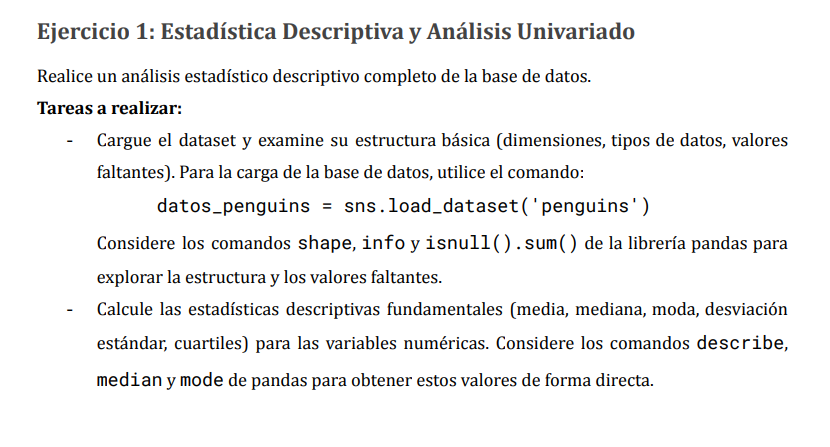

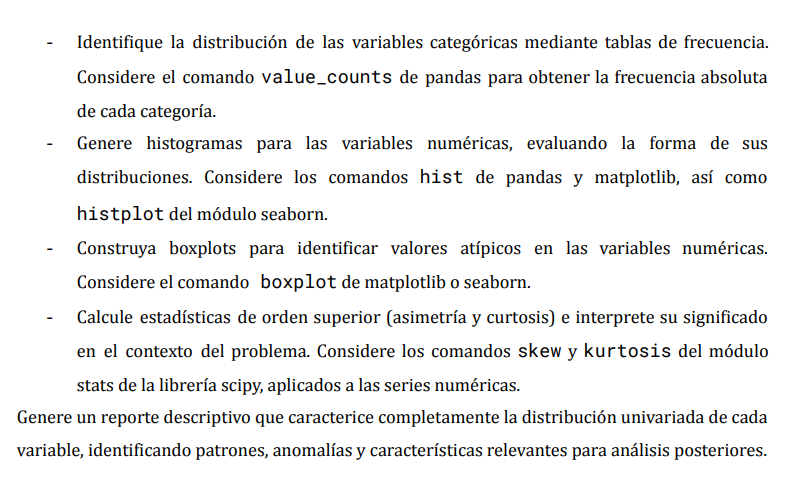

(344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


Datos faltantes:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  

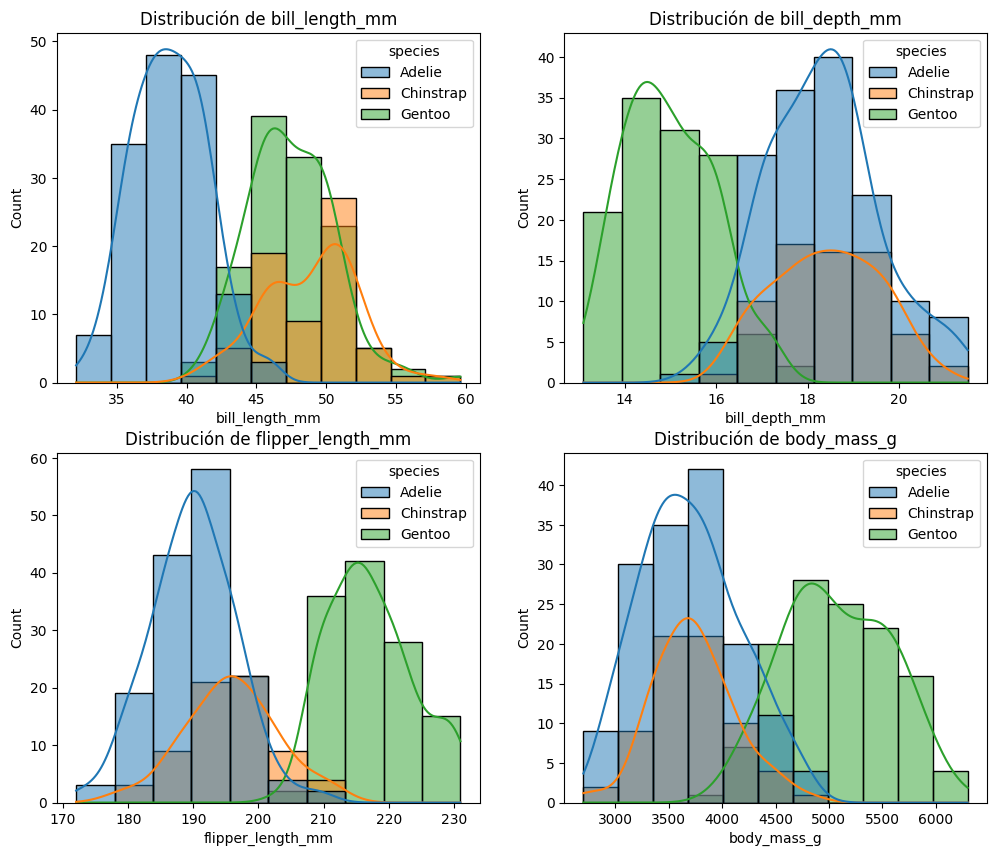

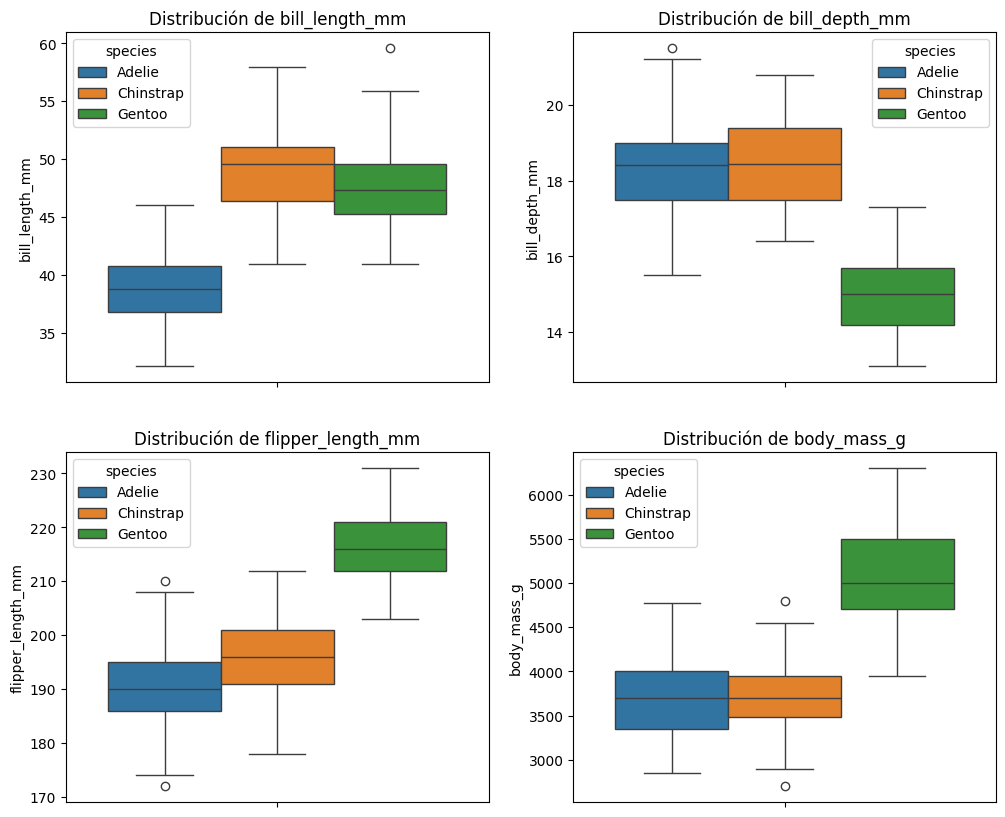

In [ ]:
datos_pinguinos = sns.load_dataset('penguins')
#Uso de .shape, .info(), isnull().sum()
print(datos_pinguinos.shape)
print(datos_pinguinos.info())
print("\n")
print('Datos faltantes:')
print(datos_pinguinos.isnull().sum())

print("\n")
#Cálculo de características de estadística descriptiva
estadisticos_principales = datos_pinguinos.describe()
print(estadisticos_principales)
print("\n")
mediana_features = datos_pinguinos.median(axis=0, numeric_only=True)
moda_features = datos_pinguinos.mode(axis=0, numeric_only=True)
print(f"Mediana de las features: {mediana_features}")
print("\n")
print(f"Moda de las features: {moda_features}")

print("\n")
#Análisis de las variables categóricas
freq_species = datos_pinguinos['species'].value_counts()
freq_sex = datos_pinguinos['sex'].value_counts()
freq_island = datos_pinguinos['island'].value_counts()

print(f"Cantidad de pinguinos por especie: {freq_species}")
print("\n")
print(f"Cantidad de pinguinos por sexo: {freq_sex}")
print("\n")
print(f"Cantidad de pinguinos por isla: {freq_island}")
print("\n")

#ANÁLISIS DE LAS VARIABLES NUMÉRICAS
fig, axs = plt.subplots(2,2, figsize=(12,10))
variables = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']

for ax, var in zip(axs.flatten(), variables):
  sns.histplot(data=datos_pinguinos,x=var, hue='species', kde=True, ax=ax) #kde agregar una curva suave que representa la distribución de los datos. ax indica el gráfico a plotear.
  #x indica la variable a colocar en el eje horizontal. data indica de dónde salen los datos.
  ax.set_title(f"Distribución de {var}")

fig2, axs2 = plt.subplots(2,2, figsize=(12,10))
for ax, var in zip(axs2.flatten(), variables):
  sns.boxplot(data=datos_pinguinos,hue='species',y=var,ax=ax) #Graficamos boxplot. 'y' indica la variable de interés a representar con el box plot.
  ax.set_title(f"Distribución de {var}")
print("\n")
for var in variables:
  datos = datos_pinguinos[var].dropna()
  skewness = skew(datos)
  curtosis = kurtosis(datos) #por defecto, el parametro fisher = True. Es decir, esta es la 'exceso de kurtosis'. (Normal = 0)
  print(f"Asimetría de la feature {var}: {skewness:.2f}. Curtosis: {curtosis:.2f}")


#CONCLUSIONES SOBRE LOS DATOS
#Las frecuencias absolutas de especie e isla están desbalanceadas. Hay pocos individuos de la especie Chinstrap comparado contra las otras dos especies.
#Existen pocos individuos en la isla Torgesen en comparación a los hallados en las otras islas. Esto podría deberse, bien a que existen efectivamente
#menos pinguinos en esta isla, o porque se muestreó más en las otras islas.

#Existen pocos datos nulos. Sexo es la que más tiene, pero son solamente 11 (menor al 5% del tamaño del dataset).
#En cuanto a las variables numéricas, podemos observar que ninguna distribución se asemeja a una gaussiana.
#La longitud de pico y de aleta parecieran ser bimodales.
#La masa parece tener una asimetría hacia la derecha.
#El espesor de pico presenta una distribución más "rara", con concentración de frecuencia alrededor de 14 a 18.

In [ ]:
estadisticos_principales.round()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.0,342.0,342.0,342.0
mean,44.0,17.0,201.0,4202.0
std,5.0,2.0,14.0,802.0
min,32.0,13.0,172.0,2700.0
25%,39.0,16.0,190.0,3550.0
50%,44.0,17.0,197.0,4050.0
75%,48.0,19.0,213.0,4750.0
max,60.0,22.0,231.0,6300.0


* Dimensiones globales: 344 filas y 7 columnas.
* Completitud: Las variables numéricas presentan únicamente 2 registros nulos (0.58). La variable nominal sex registra 11 nulos (3.2). El dataset cuenta con un 96.8 de registros completos, por lo que los valores faltantes no comprometen la representatividad del análisis global.

**Variables Categóricas**

* species: Distribución desbalanceada liderada por Adelie (152 individuos, 44.2%), seguida por Gentoo (124, 36.0 % Chinstrap (68, 19.8%).
* island: Concentración mayoritaria en Biscoe (168, 48.8)%, intermedia en Dream (124, 36.0%) y minoritaria en Torgersen (52, 15.1%).
* sex: Distribución prácticamente balanceada entre Male (168, $50.45) y Female (165, 49.55%) sobre los casos válidos.


**Variables Numéricas**

Largo del Pico (bill_length_mm)

* Estadísticos: Media = 43.92 mm, Mediana = 44.45, Moda puntual = 41.1 mm, Asimetría = 0.05, Curtosis = -0.88.
* Diagnóstico: Los estadísticos de tendencia central sugieren simetría (Media cercana a mediana y asimetria practicamente nula). Sin embargo, la curtosis y el histograma confirman que no es una distribución gaussiana, sino una distribución bimodal simétrica con dos picos pronunciados en torno a los 40 mm y 47mm. La caja del boxplot se muestra centrada debido al balance entre ambos lóbulos.

Profundidad del Pico (bill_depth_mm)

* Estadísticos: Media = 17.15 mm, Mediana = 17.30 mm, Moda puntual = 17.0 mm, Asimetría = -0.14, Curtosis = -0.91.
* Diagnóstico: La coincidencia de media, mediana y moda emula una campana regular, pero el coeficiente negativo (-0.14) y el gráfico revelan una asimetría hacia la izquierda con mayor densidad en valores altos (17--19 mm) y una cola que desciende hacia valores bajos (13--15 mm). Su marcada curtosis negativa refleja una morfología aplanada de hombros anchos sin outliers.

Largo de la Aleta (flipper_length_mm)

* Estadísticos: Media =200.91 mm, Mediana = 197.0 mm, Moda puntual = 190.0 mm, Asimetría = 0.34, Curtosis = -0.99.
* Diagnóstico: La relación Media > Mediana > Moda y la asimetría positiva se traducen en el gráfico como una bimodalidad severa. Presenta dos grupos nítidamente separados: un pico primario en 190--195 mm y un segundo pico en 215--220 mm, separados por un valle en aprox 205 mm. En el boxplot, la mediana se desplaza hacia la parte inferior de la caja.

Masa Corporal (body_mass_g)

* Estadísticos: Media = 4201.75 g, Mediana = 4050.0 g, Moda puntual = 3800.0 g, Asimetría = 0.47, Curtosis = -0.73.
* Diagnóstico: Es la variable con asimetría positiva más definida. La distribución es unimodal con la mayor concentración de individuos entre 3500 g y 4000 g y una cola extendida hacia la derecha que alcanza los 6300 g. El boxplot refleja esta asimetría con una mediana más baja respecto a la dispersión superior y un rango amplio (std aprox 802 g).

En conclusion el análisis evidencia que los estadísticos de tendencia central y asimetría de forma aislada pueden inducir a diagnósticos erróneos de normalidad (como en 'bill_length_mm' o 'bill_depth_mm'). La combinación de métricas de forma (curtosis negativa) con histogramas y curvas de densidad resulta indispensable para detectar la presencia de distribuciones multimodales y mezclas de subpoblaciones.

#Ejercicio 2

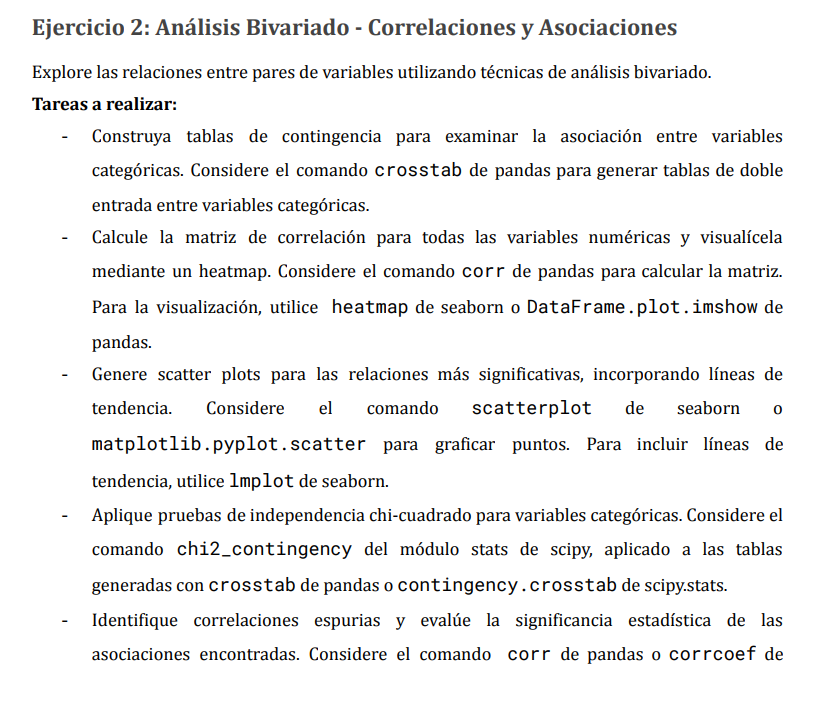

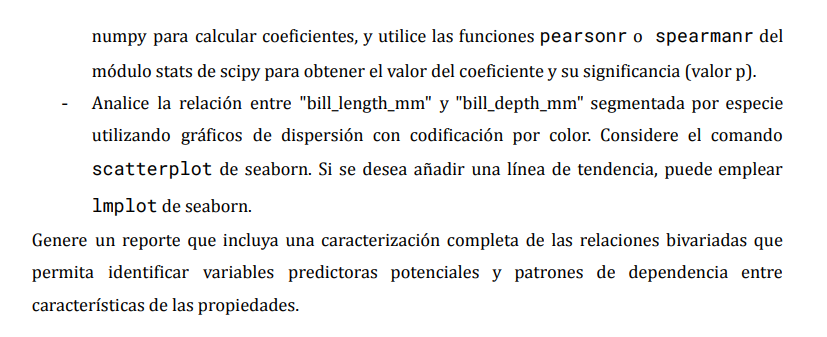

Tabla de contingencia entre especie e isla
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


Tabla de contingencia entre escpecie y sexo
species  Adelie  Chinstrap  Gentoo
sex                               
Female       73         34      58
Male         73         34      61


Tabla de contingencia entre sexo e isla
island  Biscoe  Dream  Torgersen
sex                             
Female      80     61         24
Male        83     62         23


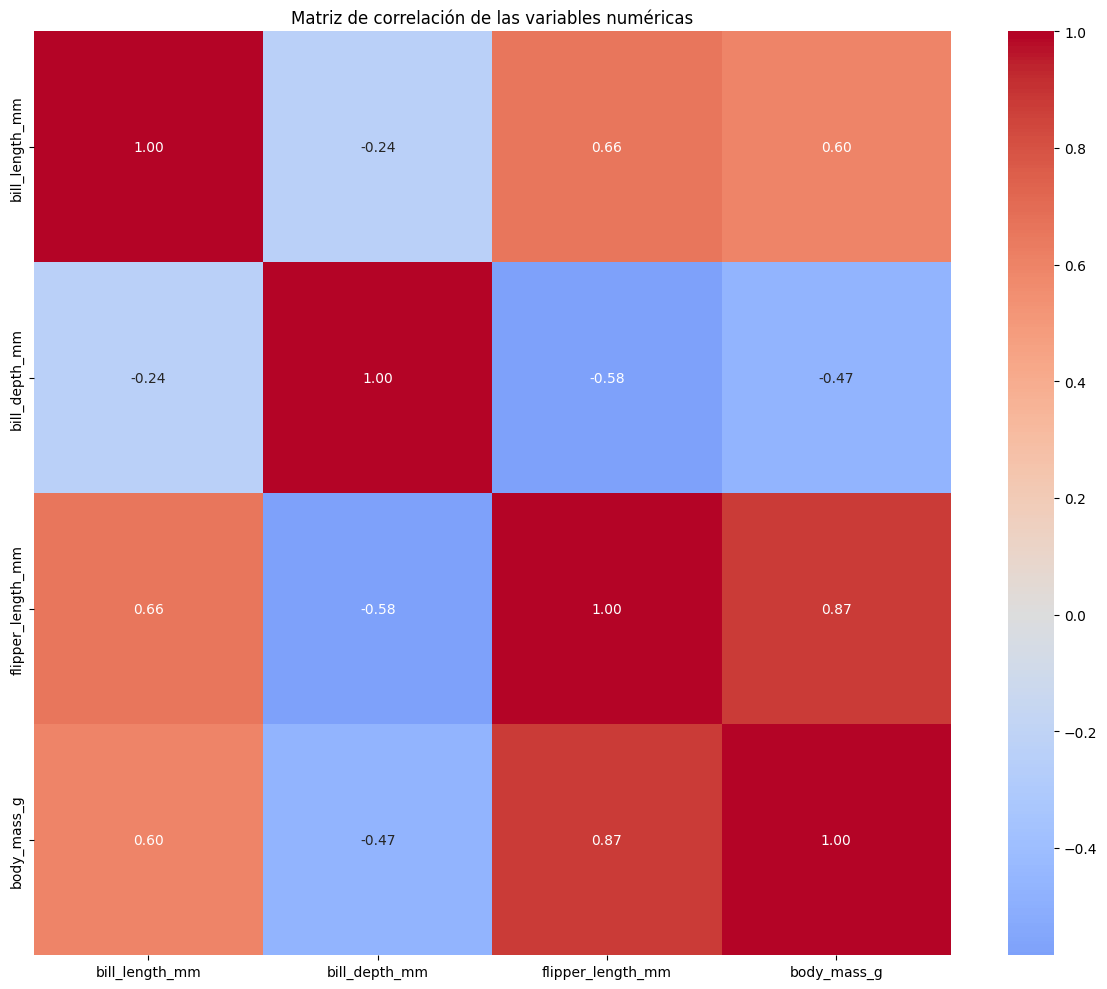

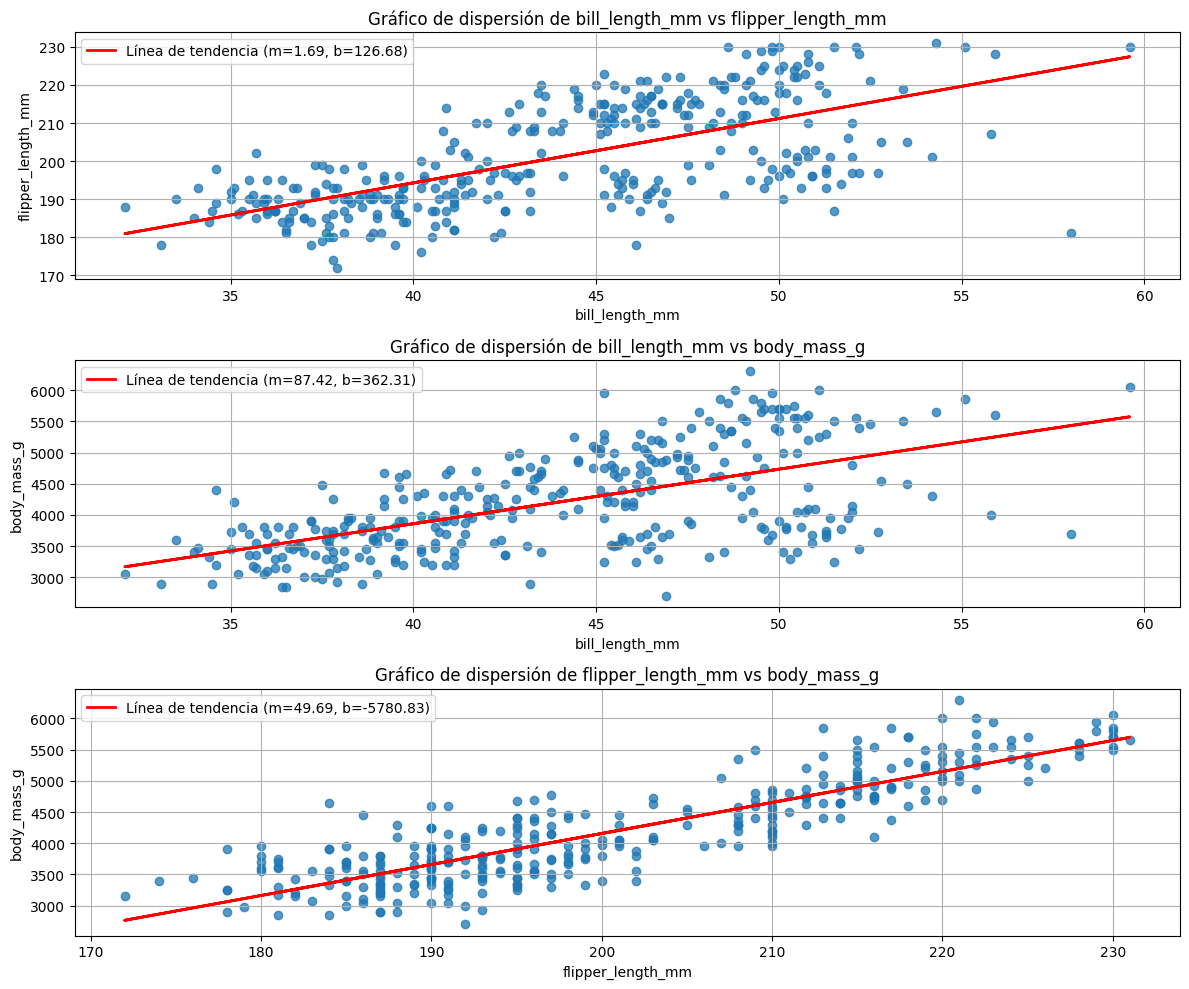

In [ ]:
#Construya tablas de contingencia para examinar la asociación entre variables
#categóricas. Considere el comando crosstab de pandas para generar tablas de doble
#entrada entre variables categóricas.

print("Tabla de contingencia entre especie e isla") #Creamos las tablas de contingenica para cada par de features categóricas.
tabla_contingencia_especie_isla = pd.crosstab(datos_pinguinos['species'],datos_pinguinos['island'])
print(tabla_contingencia_especie_isla)
print("\n")
print("Tabla de contingencia entre escpecie y sexo")
tabla_contingencia_especie_sexo = pd.crosstab(datos_pinguinos['sex'],datos_pinguinos['species'])
print(tabla_contingencia_especie_sexo)
print("\n")
print("Tabla de contingencia entre sexo e isla")
tabla_contingencia_sexo_isla = pd.crosstab(datos_pinguinos['sex'],datos_pinguinos['island'])
print(tabla_contingencia_sexo_isla)

#Calcule la matriz de correlación para todas las variables numéricas y visualícela
#mediante un heatmap. Considere el comando corr de pandas para calcular la matriz.
#Para la visualización, utilice heatmap de seaborn o DataFrame.plot.imshow de
#pandas.
matriz_correlacion_numericas = datos_pinguinos.corr(numeric_only=True) #Calcula la matriz de correlación sólo para las features numéricas.
plt.figure(figsize=(12,10))
sns.heatmap(matriz_correlacion_numericas, annot=True,cmap='coolwarm', center=0, fmt='.2f')
plt.title("Matriz de correlación de las variables numéricas")
plt.tight_layout()
plt.show()

#Genere scatter plots para las relaciones más significativas, incorporando líneas de
#tendencia. Considere el comando scatterplot de seaborn o
#matplotlib.pyplot.scatter para graficar puntos. Para incluir líneas de
#tendencia, utilice lmplot de seaborn.
pares_ploteados = [['bill_length_mm', 'flipper_length_mm'], ['bill_length_mm', 'body_mass_g'],['flipper_length_mm', 'body_mass_g']] #Array con los pares de features a analizar.
cantidad_pares = len(pares_ploteados)

fig3, axs3 = plt.subplots(cantidad_pares,1, figsize=(12,10))
for i, par in enumerate(pares_ploteados): #recorremos cada par.
  datos_limpios = datos_pinguinos[[par[0], par[1]]].dropna()
  x, y = datos_limpios[par[0]], datos_limpios[par[1]] #ignoramos los registros sin valor (son pocos, por lo que no tienen mucho impacto).
  m, b = np.polyfit(x,y,1) #calculamos línea de tendencia.
  axs3[i].scatter(x, y, alpha=0.75) #graficamos los puntos.
  axs3[i].plot(x, m*x+b, linewidth=2.0, color='red', label=f"Línea de tendencia (m={m:.2f}, b={b:.2f})") #gráficamos la línea de tendencia
  axs3[i].set_xlabel(f"{par[0]}")
  axs3[i].set_ylabel(f"{par[1]}")
  axs3[i].set_title(f"Gráfico de dispersión de {par[0]} vs {par[1]}")
  axs3[i].grid()
  axs3[i].legend()

plt.tight_layout()
plt.show()





In [ ]:
#Identifique correlaciones espurias y evalúe la significancia estadística de las
#asociaciones encontradas. Considere el comando corr de pandas o corrcoef de
#numpy para calcular coeficientes, y utilice las funciones pearsonr o spearmanr del
#módulo stats de scipy para obtener el valor del coeficiente y su significancia (valor p)

cols = datos_pinguinos.select_dtypes('number').columns
filas = []

for col1, col2 in itertools.combinations(cols, 2): #genera todas las posibles combinaciones de longitud 2 de los elemenros de cols

    df_limpia = datos_pinguinos[[col1, col2]].dropna()

    #pearson
    r_p, p_p = stats.pearsonr(df_limpia[col1], df_limpia[col2])

    #spearman
    r_s, p_s = stats.spearmanr(df_limpia[col1], df_limpia[col2])

    filas.append(
        {
            'Par de Variables' : f'{col1} vs {col2}',
            'Pearson (r)' : round(r_p,4),
            'Significancia Pearson' : round(p_p, 5),
            'Spearman (rho)' : round(r_s, 4),
            'Significancia Spearman' : round(p_s, 5)
        }
    )

tabla_correlaciones = pd.DataFrame(filas)

tabla_correlaciones.head(6)



,Par de Variables,Pearson (r),Significancia Pearson,Spearman (rho),Significancia Spearman
0,bill_length_mm vs bill_depth_mm,-0.2351,0.00001,-0.2217,0.00004
1,bill_length_mm vs flipper_length_mm,0.6562,0.00000,0.6728,0.00000
2,bill_length_mm vs body_mass_g,0.5951,0.00000,0.5838,0.00000
3,bill_depth_mm vs flipper_length_mm,-0.5839,0.00000,-0.5233,0.00000
4,bill_depth_mm vs body_mass_g,-0.4719,0.00000,-0.4324,0.00000
5,flipper_length_mm vs body_mass_g,0.8712,0.00000,0.8400,0.00000


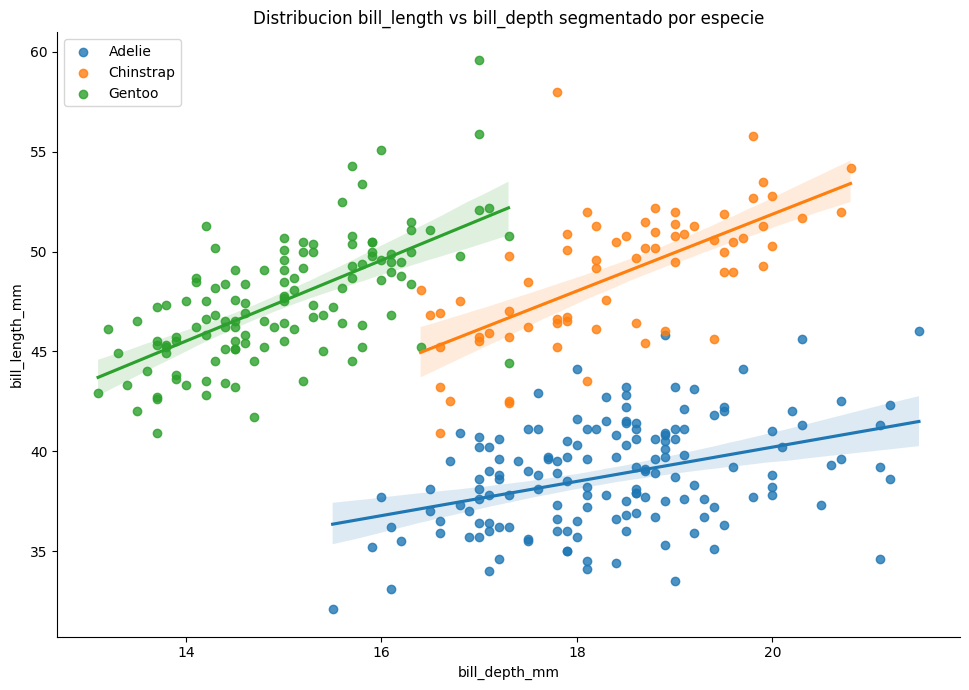

In [ ]:
#Analice la relación entre "bill_length_mm" y "bill_depth_mm" segmentada por especie
#utilizando gráficos de dispersión con codificación por color. Considere el comando
#scatterplot de seaborn. Si se desea añadir una línea de tendencia, puede emplear
#lmplot de seaborn.

sns.lmplot(data= datos_pinguinos, x='bill_depth_mm', y = 'bill_length_mm', hue='species', height=7, aspect=1.4, legend=False)
plt.title('Distribucion bill_length vs bill_depth segmentado por especie')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Al analizar los graficos vemos que ocurre algo muy interesante. Los coeficientes de Pearson y Spearman mostraban una correlacion negativa, pero al graficar las variables segmentadas por especie es posible apreciar una clara correlacion positiva.

Este fenómeno se conoce como la Paradoja de Simpson y ocurre cuando se calcula una correlación global ignorando una variable clave, en este caso la especie. Dentro de cada especie existe una relación positiva donde ambas medidas crecen juntas, pero entre especies las características morfológicas promedio son muy distintas. Al juntar todos los grupos en un solo análisis sin diferenciarlos, la posición relativa de cada especie en el plano distorsiona la tendencia y genera una correlación negativa global aparente que oculta la verdadera relación dentro de cada grupo.

In [ ]:
# Construya tablas de contingencia para examinar la asociación entre variables
# categóricas. Considere el comando crosstab de pandas para generar tablas de doble
# entrada entre variables categóricas.

# Aplique pruebas de independencia chi-cuadrado para variables categóricas. Considere el
# comando chi2_contingency del módulo stats de scipy, aplicado a las tablas
# generadas con crosstab de pandas o contingency.crosstab de scipy.stats.

#Tabla especie-sexo
print('Tabla Especie-Sexo', '\n')
especie_sexo = pd.crosstab(index=datos_pinguinos['species'], columns=datos_pinguinos['sex'])
chi2, p_val, dof, esperadas_array = stats.chi2_contingency(especie_sexo)
esperadas =  pd.DataFrame(esperadas_array, index = especie_sexo.index, columns = especie_sexo.columns).round(2)

print('Frecuencias observadas')
print(especie_sexo,'\n')

print('Frecuencias esperadas')
print(esperadas,'\n')

#Tabla especie-isla
print('Tabla Especie-Isla', '\n')
especie_isla = pd.crosstab(index=datos_pinguinos['species'], columns=datos_pinguinos['island'])
chi2, p_val, dof, esperadas_array = stats.chi2_contingency(especie_isla)
esperadas =  pd.DataFrame(esperadas_array, index = especie_isla.index, columns = especie_isla.columns).round(2)

print('Frecuencias observadas')
print(especie_isla,'\n')

print('Frecuencias esperadas')
print(esperadas, '\n')

#Tabla sexo-isla
print('Tabla Sexo-Isla', '\n')
sexo_isla = pd.crosstab(index=datos_pinguinos['sex'], columns=datos_pinguinos['island'])
chi2, p_val, dof, esperadas_array = stats.chi2_contingency(sexo_isla)
esperadas =  pd.DataFrame(esperadas_array, index = sexo_isla.index, columns = sexo_isla.columns).round(2)

print('Frecuencias observadas')
print(sexo_isla,'\n')

print('Frecuencias esperadas')
print(esperadas)

Tabla Especie-Sexo 

Frecuencias observadas
sex        Female  Male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61 

Frecuencias esperadas
sex        Female   Male
species                 
Adelie      72.34  73.66
Chinstrap   33.69  34.31
Gentoo      58.96  60.04 

Tabla Especie-Isla 

Frecuencias observadas
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0 

Frecuencias esperadas
island     Biscoe  Dream  Torgersen
species                            
Adelie      74.23  54.79      22.98
Chinstrap   33.21  24.51      10.28
Gentoo      60.56  44.70      18.74 

Tabla Sexo-Isla 

Frecuencias observadas
island  Biscoe  Dream  Torgersen
sex                             
Female      80     61         24
Male        83     62         23 

Frecuencias esperadas
island  Biscoe  Dream  Torgersen
sex                      

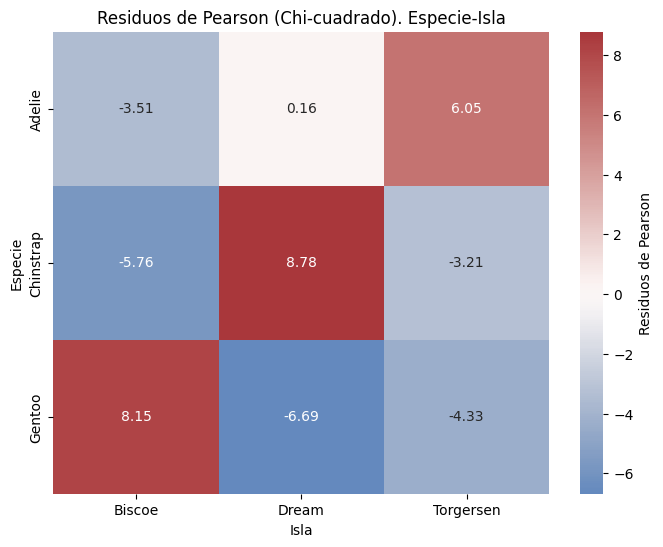

In [ ]:
contingency_table = pd.crosstab(
    datos_pinguinos['species'], datos_pinguinos['island']
)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

#Residuos de Pearson: (observado - esperado) / sqrt(esperado)
observed = contingency_table.values
pearson_residuals = (observed - expected) / np.sqrt(expected)
df_residuals = pd.DataFrame(
    pearson_residuals,
    index=contingency_table.index,
    columns=contingency_table.columns,
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_residuals,
    annot=True,
    fmt=".2f",
    cmap="vlag",  #Paleta divergente: azul (negativos) a rojo (positivos)
    center=0,
    cbar_kws={"label": "Residuos de Pearson"},
)

plt.title("Residuos de Pearson (Chi-cuadrado). Especie-Isla")
plt.xlabel("Isla")
plt.ylabel("Especie")
plt.show()

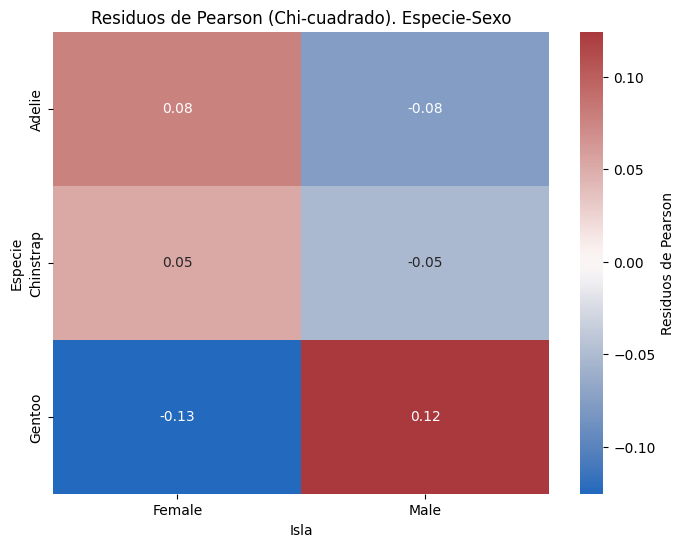

In [ ]:
contingency_table = pd.crosstab(
    datos_pinguinos['species'], datos_pinguinos['sex']
)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

#Residuos de Pearson: (observado - esperado) / sqrt(esperado)
observed = contingency_table.values
pearson_residuals = (observed - expected) / np.sqrt(expected)
df_residuals = pd.DataFrame(
    pearson_residuals,
    index=contingency_table.index,
    columns=contingency_table.columns,
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_residuals,
    annot=True,
    fmt=".2f",
    cmap="vlag",  #Paleta divergente: azul (negativos) a rojo (positivos)
    center=0,
    cbar_kws={"label": "Residuos de Pearson"},
)

plt.title("Residuos de Pearson (Chi-cuadrado). Especie-Sexo")
plt.xlabel("Isla")
plt.ylabel("Especie")
plt.show()

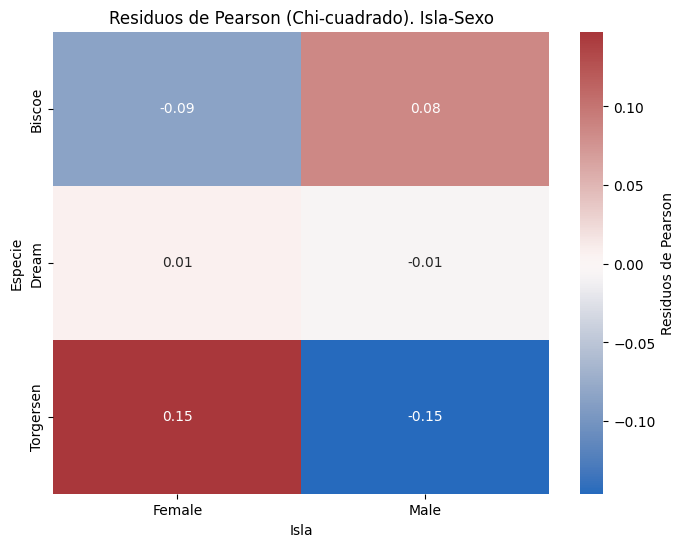

In [ ]:
contingency_table = pd.crosstab(
    datos_pinguinos['island'], datos_pinguinos['sex']
)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

#Residuos de Pearson: (observado - esperado) / sqrt(esperado)
observed = contingency_table.values
pearson_residuals = (observed - expected) / np.sqrt(expected)
df_residuals = pd.DataFrame(
    pearson_residuals,
    index=contingency_table.index,
    columns=contingency_table.columns,
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_residuals,
    annot=True,
    fmt=".2f",
    cmap="vlag",  #Paleta divergente: azul (negativos) a rojo (positivos)
    center=0,
    cbar_kws={"label": "Residuos de Pearson"},
)

plt.title("Residuos de Pearson (Chi-cuadrado). Isla-Sexo")
plt.xlabel("Isla")
plt.ylabel("Especie")
plt.show()

Boxplots comparativos discrimiandos por especie

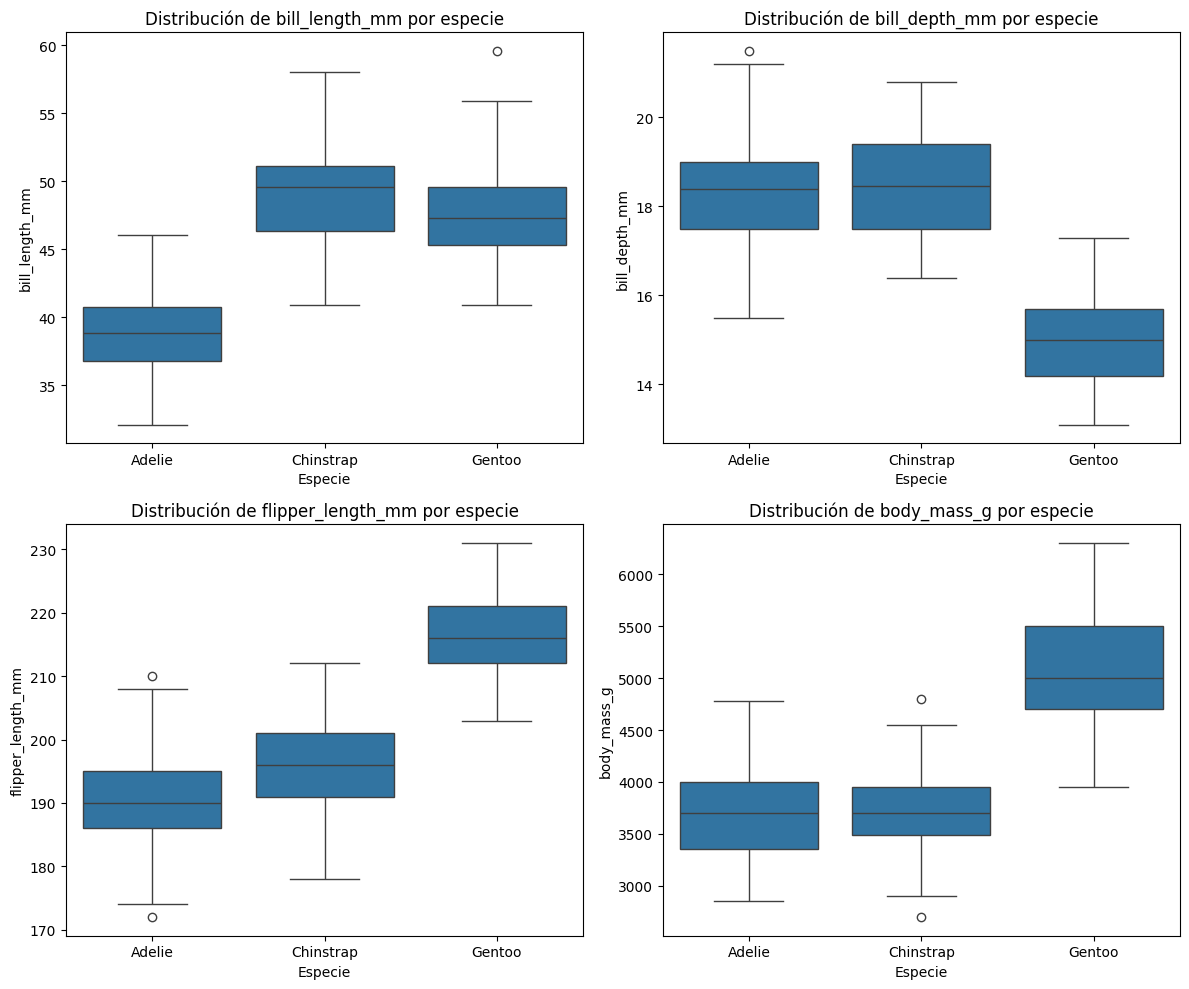

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

cols = datos_pinguinos.select_dtypes('number').columns # Defining 'cols' based on previous cells where it's used for numerical columns

for ax, col in zip(axs.flatten(), cols):
 sns.boxplot(data=datos_pinguinos, x='species', y=col, ax=ax)
 ax.set_title(f'Distribución de {col} por especie')
 ax.set_xlabel('Especie')
 ax.set_ylabel(col)

plt.tight_layout()
plt.show()

**Reporte**

Empezamos con un análisis de las variables categóricas.

Analizando las tablas de contingencia y comparando las frecuencias observadas con las esperadas después de aplicar el test de chi-cuadrado, podemos llegar a las siguientes conclusiones:

* **Especie-Sexo:** Las frecuencias observadas coinciden prácticamente en su totalidad con las frecuencias esperadas, siendo la mayor desviación de 0.96, correspondiente a la interacción del sexo 'Male' con la especie 'Gentoo.
Al observar la matriz de residuos de Pearson, la mayor desviación estandarizada corresponde a 'Gentoo-Female' con -0.13 (y 0.12 en 'Gentoo-Male').
En este caso se obtuvo un valor de chi^2=0.0486

Dado que las desviaciones son muy pequeñas y el valor de chi^2 también es muy bajo, podemos concluir que no existe evidencia de una asociación significativa entre las variables Especie y Sexo.

* **Especie-Isla:** Las frecuencias observadas difieren considerablemente respecto a las esperadas, siendo la diferencia mínima de 1.21 y la máxima de 63.44, correspondiente a la especie 'Gentoo' y la isla 'Biscoe'.
Al complementar con los residuos de Pearson, se observa que la mayor concentración relativa atípica corresponde a 'Chinstrap-Dream' (8.78) y 'Gentoo-Biscoe' (8.15), mientras que la menor desviación relativa la registra 'Adelie-Dream' (0.16)

Al aplicar nuevamente el test de chi-cuadrado, utilizando las diferencias entre las frecuencias observadas y esperadas, se obtiene chi^2=299.5503.

Estos valores, especialmente el p-value extremadamente bajo, permiten concluir que existe una asociación estadísticamente significativa entre las variables Especie e Isla. La gran diferencia entre las frecuencias observadas y esperadas explica el elevado valor del estadístico chi-cuadrado.

Además, resulta particularmente llamativa la relación entre 'Gentoo' y 'Biscoe': se observaron 124 individuos Gentoo en Biscoe, mientras que bajo el supuesto de independencia se esperarían aproximadamente 60.56. Esta diferencia de 63.44 es la mayor desviación observada en esta tabla de contingencia.

* **Sexo-Isla:** Al igual que con el primer par de variables, las frecuencias observadas y esperadas presentan una diferencia extremadamente baja, siendo la mayor desviación de 0.77, correspondiente al sexo 'Male' y la isla 'Biscoe'.
Sin embargo, al examinar los residuos de Pearson, la mayor desviación se registra en la isla Torgersen (0.15 para Female y -0.15 para Male), mientras que la isla Dream presenta la menor desviación (0.01).

Al calcular el estadístico de chi-cuadrado se obtiene chi^2=0.0576.

Estos valores permiten concluir que no existe evidencia de una asociación significativa entre Sexo e Isla, ya que las frecuencias observadas son muy similares a las esperadas bajo el supuesto de independencia.

A su vez, es interesante destacar que la relación más importante entre las variables categóricas se encuentra entre Especie e Isla. Mientras que 'Gentoo-Biscoe' presenta la mayor diferencia absoluta en número de individuos, 'Chinstrap-Dream' alcanza el residuo de Pearson más elevado (8.78), lo que demuestra una marcada preferencia/asociación geográfica según la especie.

La diferencia absoluta (O - E) mide la cantidad neta de individuos que sobran o faltan, mientras que los residuos de Pearson dividen esa diferencia entre sqrt(E) para ajustar la escala. Por eso, aunque en Gentoo-Biscoe hay más individuos de diferencia en total (+63.44), en Chinstrap-Dream el residuo de Pearson es mayor (8.78 vs. 8.15): al partir de un grupo esperado más pequeño (24.51 individuos), su desviación resulta proporcionalmente más extrema.

Continuamos con el análisis de las variables numéricas.

Analizando los valores de los coeficientes de Pearson y Spearman, es posible comprobar que, en términos generales, ambos coeficientes tienden a presentar valores similares. Esto indica que las relaciones observadas mediante ambos métodos son consistentes, tanto desde el punto de vista lineal como desde el punto de vista de la monotonía.

Analizando los casos con los valores más altos podemos encontrar:

* **bill_length vs flipper_length:** con un r (Pearson) = 0.6562 y un rho (Spearman) = 0.6728, podemos interpretar una asociación positiva moderada-fuerte, con un comportamiento predominantemente lineal y monótono.

* **bill_length vs body_mass:** r = 0.5951 y rho = 0.5838, con una diferencia de aproximadamente 0.011, indican una asociación positiva moderada, tanto lineal como monótona.

* **bill_depth vs flipper_length:** r = -0.5839 y rho = -0.5233, con una diferencia de aproximadamente 0.06, indican una asociación negativa moderada, es decir, a medida que aumenta una variable, la otra tiende a disminuir. La similitud entre ambos coeficientes indica que este comportamiento negativo se mantiene tanto para la relación lineal como para la monótona.

* **flipper_length vs body_mass:** r = 0.8712 y rho = 0.8400, con una diferencia de aproximadamente 0.03. Es la asociación más alta de todos los pares de variables numéricas analizados, presentando una relación positiva fuerte, tanto lineal como monótona. Por este motivo, ambas variables son grandes candidatas a ser buenas variables predictoras, aunque su elevada correlación también indica que contienen información parcialmente redundante.

Cabe destacar también que, gracias al gráfico de dispersión de bill_length vs bill_depth segmentado por especies, podemos obtener un mejor contexto para interpretar los valores relativamente bajos de correlación lineal y monótona.

En este caso, se observa una relación positiva débil, aunque con una gran dispersión de los valores. La especie 'Adelie' es la que presenta una mayor dispersión de observaciones, lo que puede contribuir a que la asociación global entre ambas variables sea relativamente baja.

Otro hecho a destacar es que la especie 'Gentoo' parece ser la que presenta una menor dispersión de las tres. Esto, junto con el análisis categórico realizado previamente, refuerza la idea de que existen patrones diferenciados para esta especie. En particular, su fuerte asociación con la isla 'Biscoe' y la menor dispersión observada en algunas relaciones numéricas podrían facilitar su diferenciación respecto de las otras especies.

A su vez si analizamos los box plot discriminados por especies vemos que la especie 'Gentoo' es a la que le corresponde una caja mucho mas diferenciada que los demas, reafirmando lo analizado previamente.

Sin embargo, para afirmar que 'Gentoo' es efectivamente la especie más fácil de clasificar sería necesario comprobarlo mediante el desempeño de un modelo de clasificación y analizar métricas específicas para cada clase.


#Ejercicio 3

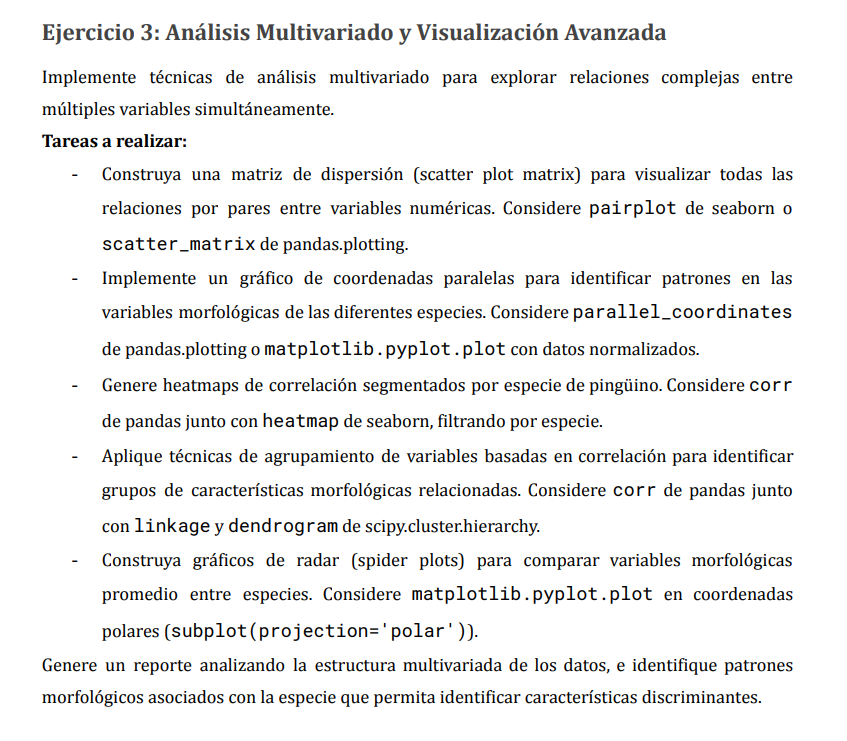

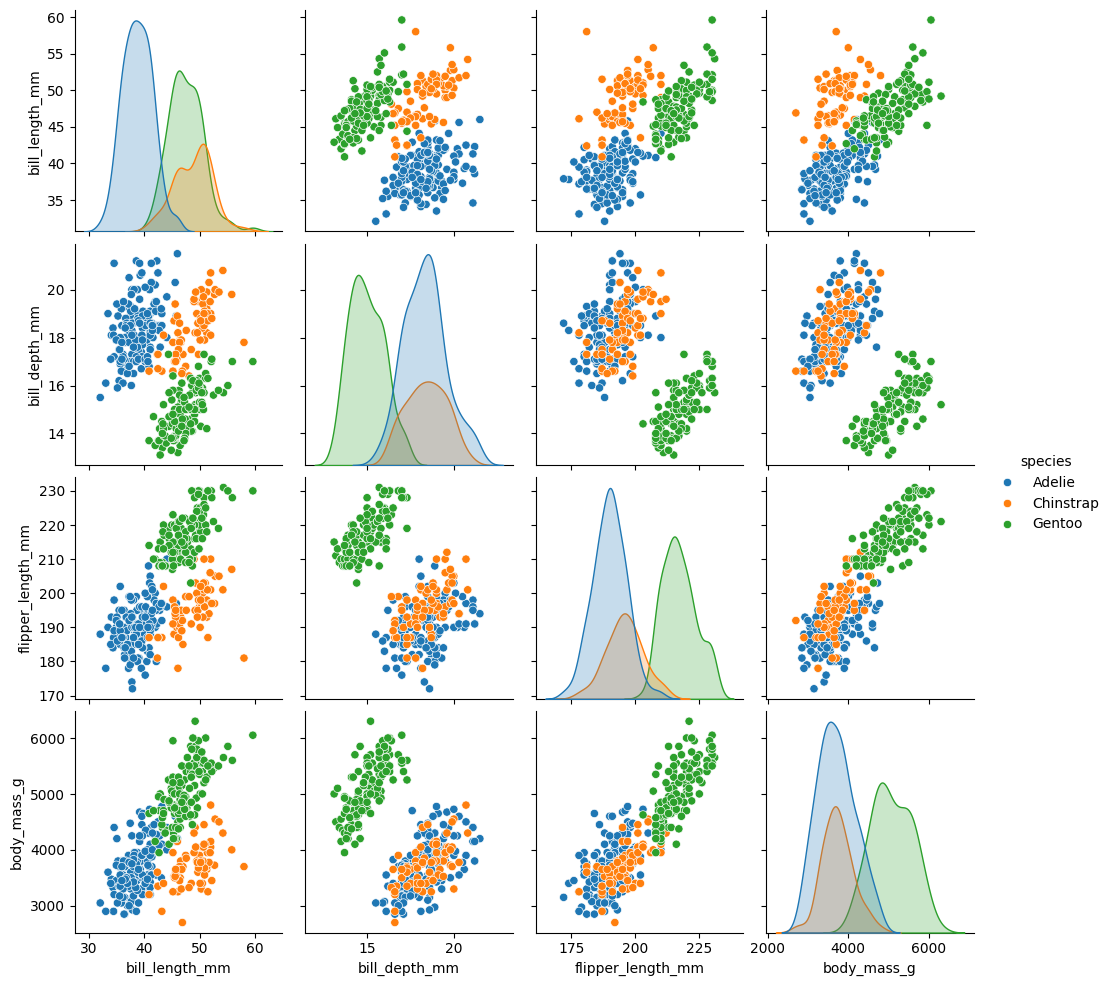

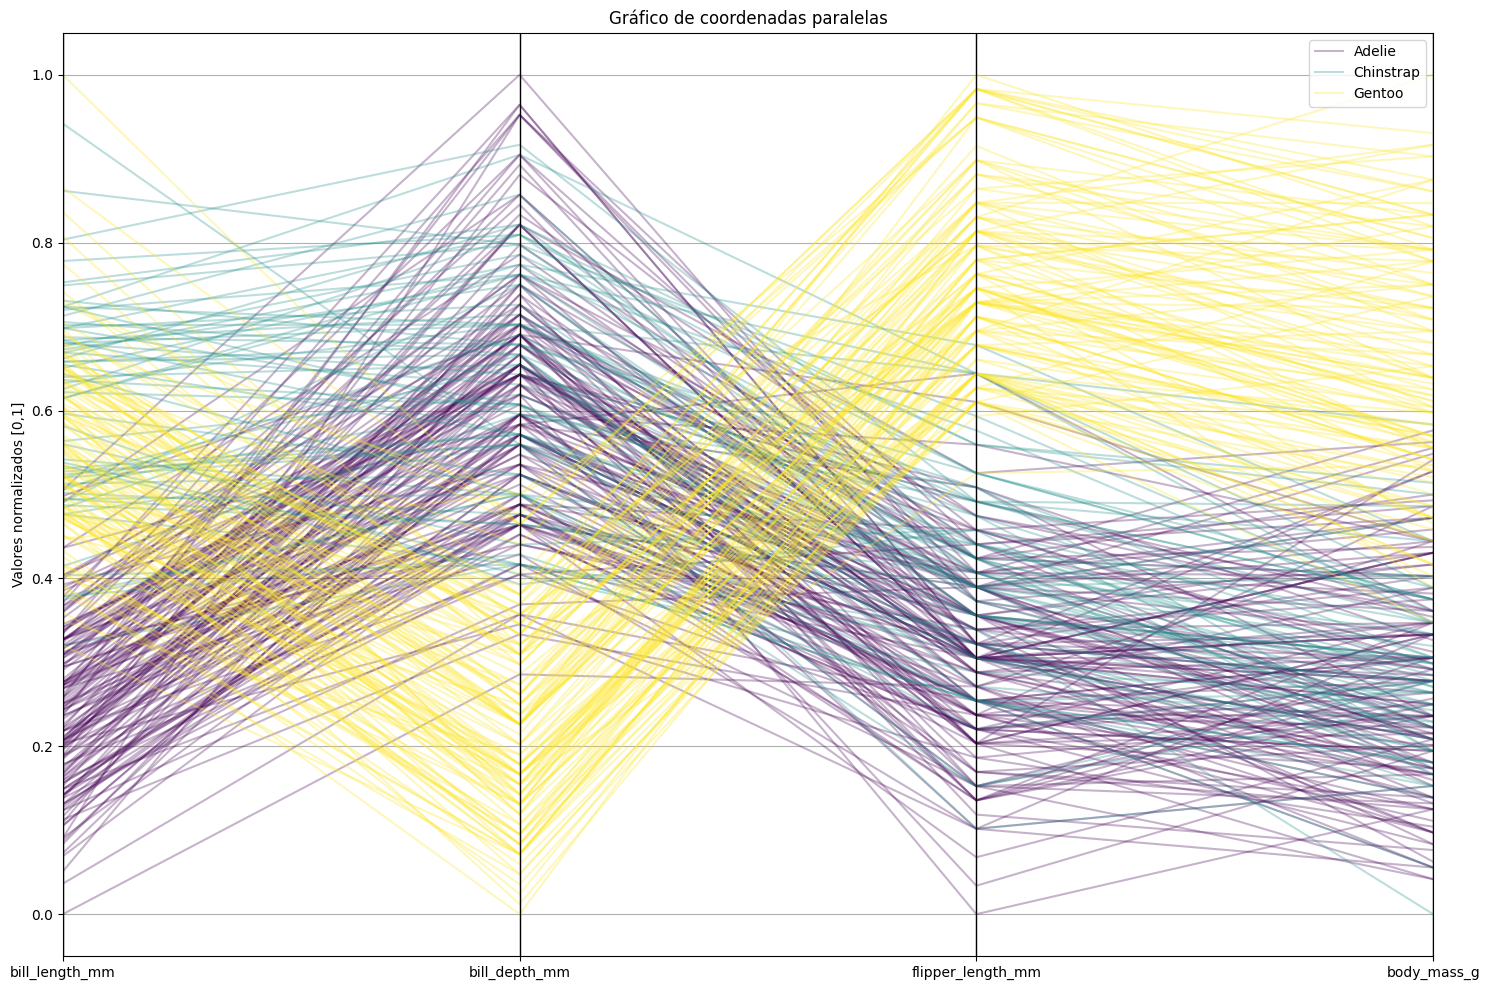

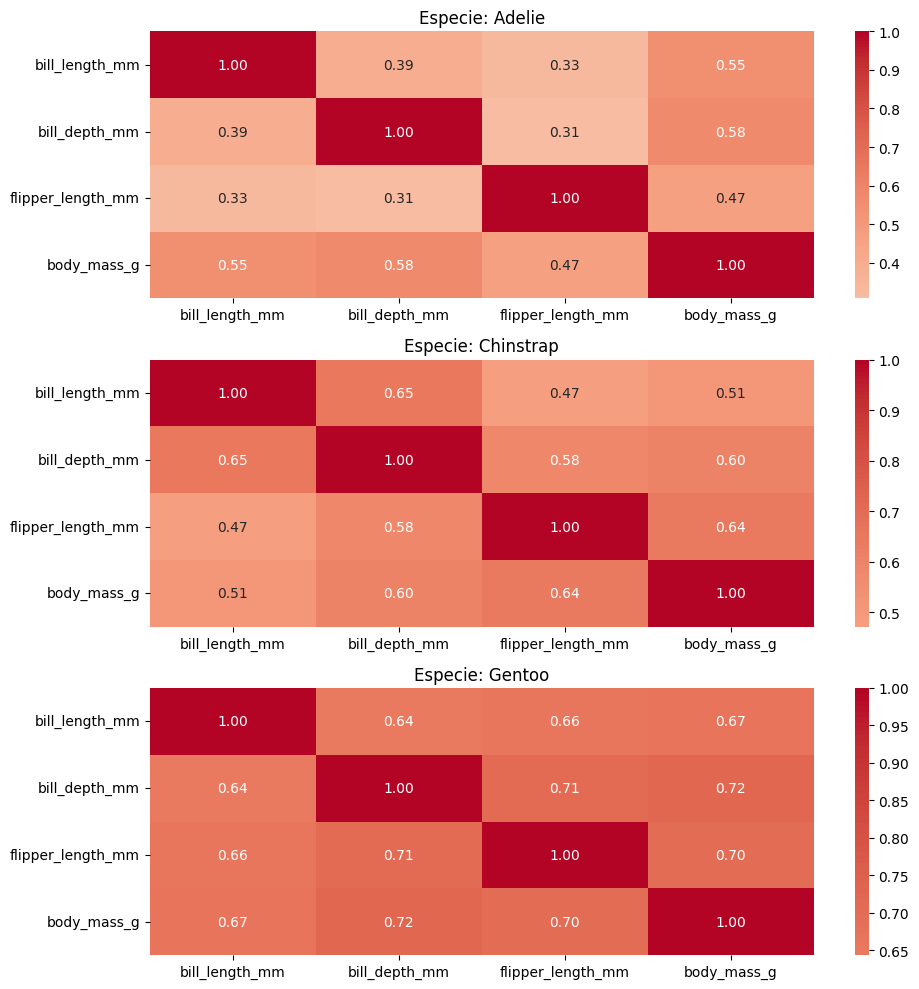

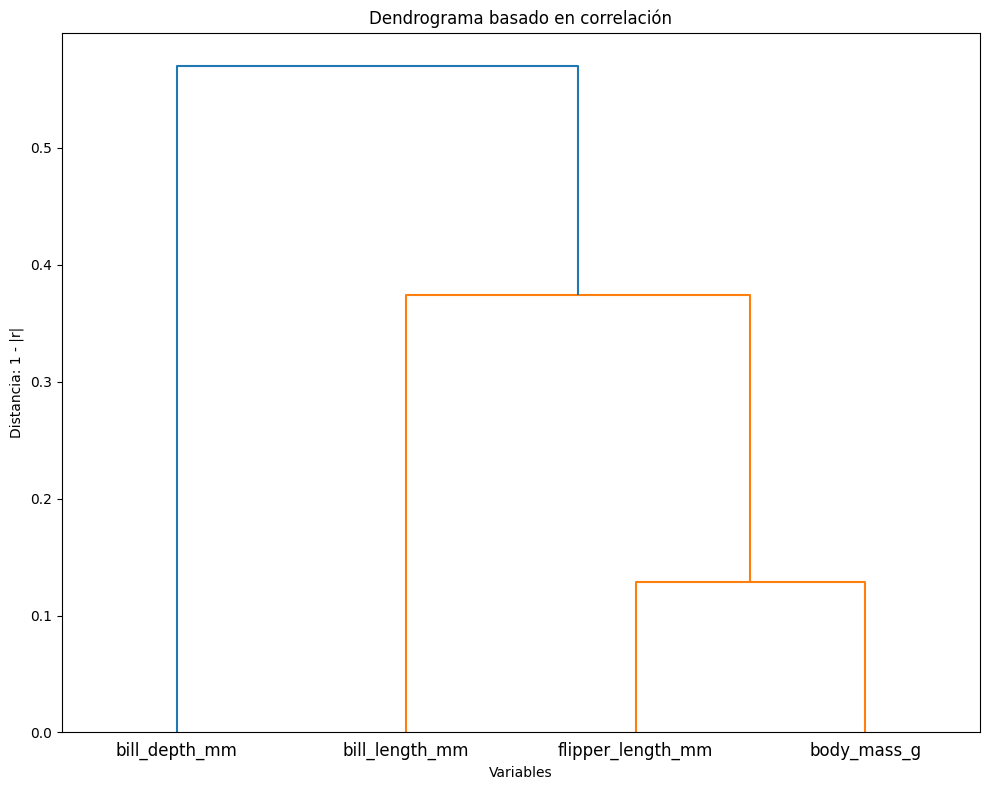

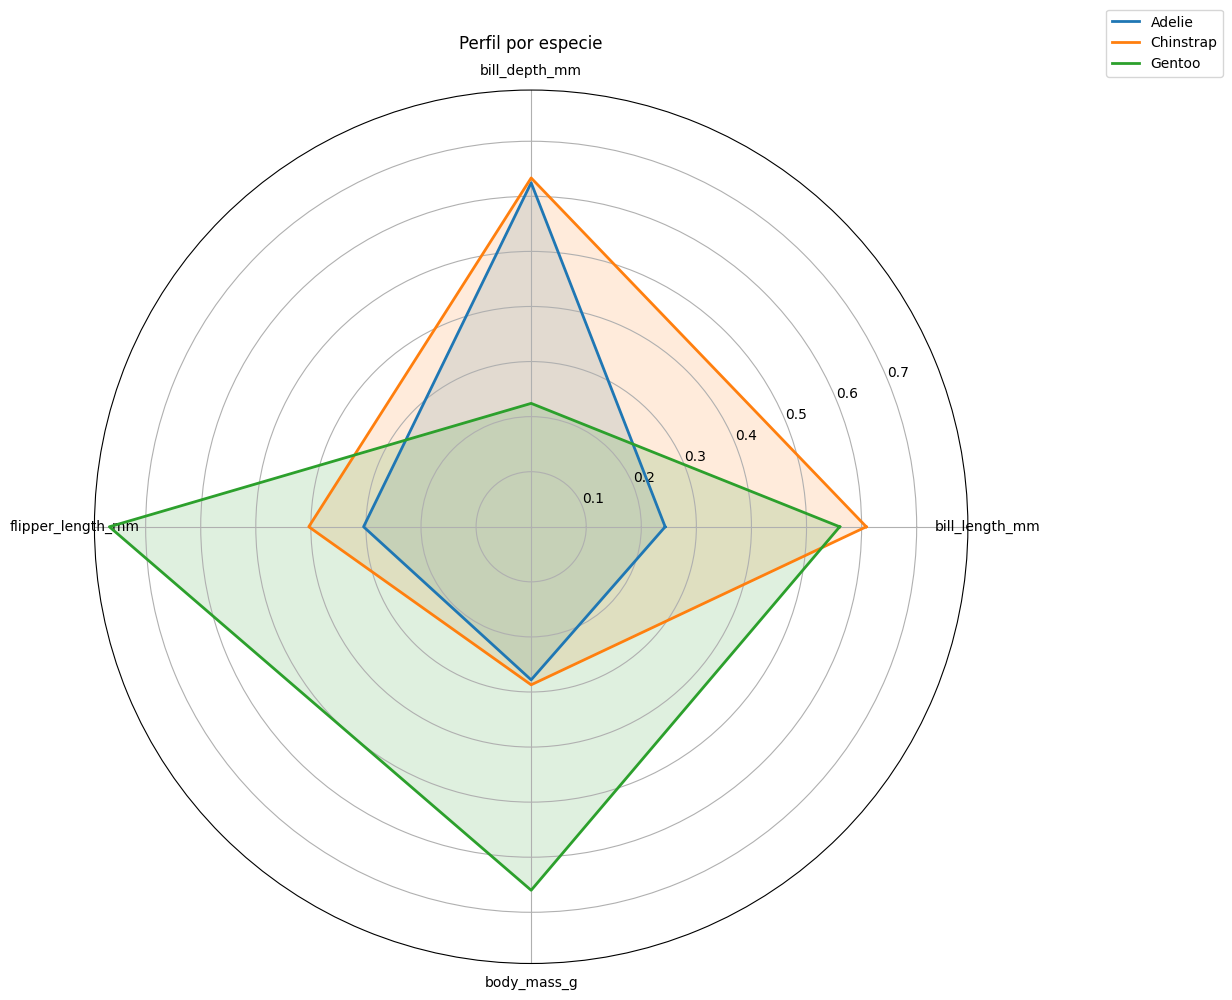

In [ ]:
#Se optó por usar sns.pairplot ya que scatter_matriz de pandas.plotting no soporta hue, y no permite graficar los puntos diferenciando por clase.

#select_dtypes devuelve un dataset igual al de pinguinos original per conservando solamente las variables numéricas.
#.columns devuelve un pandas.Index con las variables. tolist() lo transofrma en un list[str].
var_numericas = datos_pinguinos.select_dtypes(include='number').columns.tolist()
hue = 'species' #Por qué variable discriminar las observaciones.
diag_kind = 'kde' #Qué mostrar en la diagonal: 'kde' o 'hist'

sns.pairplot(datos_pinguinos, vars=var_numericas, hue='species', diag_kind='kde',corner=False) #Si corner == True sólo se muestra la parte inferior de la matriz (es simétrica).


#Implemente un gráfico de coordenadas paralelas para identificar patrones en las
#variables morfológicas de las diferentes especies. Considere parallel_coordinates
#de pandas.plotting o matplotlib.pyplot.plot con datos normalizados.
datos_ploteo = datos_pinguinos[var_numericas + ['species']].dropna()

def normalizar_columna(columna):
  return (columna-columna.min())/(columna.max()-columna.min())

data_normalizada = datos_ploteo.copy()
data_normalizada[var_numericas] = datos_ploteo[var_numericas].apply(normalizar_columna)
#parallel_coordinates() exige que la columna de clase esté físicamente presente dentro. Por eso agregamos 'species' a la lista, para que no arroke un KeyError.
plt.figure(figsize=(15,10))
parallel_coordinates(data_normalizada, class_column='species', colormap='viridis',alpha=0.3)
plt.title("Gráfico de coordenadas paralelas")
plt.ylabel("Valores normalizados [0,1]")
plt.xticks()

plt.tight_layout()
plt.show()

#Genere heatmaps de correlación segmentados por especie de pingüino. Considere corr
#de pandas junto con heatmap de seaborn, filtrando por especie.
#bill_depth_mm mostraba una correlación débil o negativa con las demás variables. Probablemente era un efecto de la
#paradoja de Simpson (mezcla de especies con morfologías distintas): segmentar el análisis por especie permite confirmar o descartar.
#Si la correlación de bill_depth_mm se vuelve positiva y fuerte dentro de cada especie individual, confirma que la correlación negativa
#global era causada por mezclar los distintos grupos, no una relación real entre esas variables.
especies = datos_pinguinos['species'].unique()
nro_especies = len(especies)
fig, axs = plt.subplots(nro_especies, 1, figsize=(10,10))
for ax, especie in zip(axs, especies):
  datos_discriminados = datos_pinguinos[datos_pinguinos['species']==especie]
  matriz_especie = datos_discriminados.corr(numeric_only=True)
  sns.heatmap(matriz_especie, annot=True, cmap='coolwarm', center=0.0, fmt='.2f', ax=ax)
  ax.set_title(f"Especie: {especie}")

plt.tight_layout()
plt.show()

#Aplique técnicas de agrupamiento de variables basadas en correlación para identificar
#grupos de características morfológicas relacionadas. Considere corr de pandas junto
#con linkage y dendrogram de scipy.cluster.hierarchy
matriz_corr = datos_pinguinos.corr(numeric_only=True)
matriz_distancia = 1 - matriz_corr.abs() #No trabajamos con correlaciones, sino con "distancias". Un valor más cercano a 1 denota que las variables son más distintas.
#squareform aplasta la matriz a un array unidimensional, solo preservando la mitad de la matriz (ya que es simétrica y dist(A,B)=dist(B,A))
distancia_condensada = squareform(matriz_distancia, checks=False) #checks controla que la diagonal sea 0 (ya que dist(A,A) = 0). Por errores numéricos, podría no ser 0 exacto. Por eso 'False'.
enlaces = linkage(distancia_condensada, method='average') #calcula el promedio de todas las distancias entre los miembros de ambos clusters.
plt.figure(figsize=(10,8))
dendrogram(enlaces, labels=matriz_corr.columns.tolist())
plt.title("Dendrograma basado en correlación")
plt.ylabel("Distancia: 1 - |r|")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

#Construya gráficos de radar (spider plots) para comparar variables morfológicas
#promedio entre especies. Considere matplotlib.pyplot.plot en coordenadas
#polares (subplot(projection='polar')).
def normalizar_minmax_global(promedios_df, dataset_completo, columnas):
    #Normaliza los promedios grupales usando el mínimo/máximo del dataset ORIGINAL (individuos),
    #no de la tabla de promedios ya agrupada. Esto evita que la especie de menor promedio en
    #una variable colapse artificialmente a 0.0 (y la de mayor promedio a 1.0), ya que con solo
    #3 categorías la normalización "interna" sobre los promedios fuerza esos extremos por construcción.
    minimo = dataset_completo[columnas].min()
    maximo = dataset_completo[columnas].max()
    return (promedios_df - minimo) / (maximo - minimo)

promedios_por_especie = datos_pinguinos.groupby('species')[var_numericas].mean()
promedios_normalizados = normalizar_minmax_global(promedios_por_especie, datos_pinguinos, var_numericas)
cantidad_variables = len(var_numericas)
angulos = np.linspace(0, 2*np.pi, cantidad_variables, endpoint=False).tolist()
angulos += angulos[:1] #devuelve una lista. Si hiciésemos angulos[0] devolvería un elemento

fig,axs = plt.subplots(figsize=(12,10), subplot_kw={'projection':'polar'}) #subplot_kw le indica que interprete los datos como (radio, angulo) en vez de (x,y).
for especie in promedios_normalizados.index:
  valores = promedios_normalizados.loc[especie].tolist() #extrae la fila de promedios normalizados correspondiente a esa especie puntual (4 valores, uno por variable).
  valores += valores[:1] #necesario para que el polígono de cada especie se cierre correctamente.
  axs.plot(angulos,valores, linewidth=2.0, label=especie)
  axs.fill(angulos, valores, alpha=0.15)

axs.set_xticks(angulos[:-1]) #excluímos el último ángulo repetido que agregamos.
axs.set_xticklabels(var_numericas)
axs.set_title("Perfil por especie", pad=30)
axs.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1)) #punto de anclaje de la leyenda. bbox_ton_anchor usa coordenadas relativas.
plt.tight_layout()
plt.show()

Reporte del análisis multivariado

La matriz de correlación global mostraba a bill_depth_mm con una asociación débil respecto a las demás variables, pero al segmentar por especie esta correlación se vuelve considerablemente más fuerte y, además, cambia de signo negativo a positivo dentro de cada grupo. Esto sugiere que la relación de bill_depth_mm con el resto de las variables era, en realidad, de una fuerza similar pero de signo/magnitud distinta entre especies, lo que al mezclarlas globalmente generaba un efecto de cancelación (paradoja de Simpson) que empobrecía artificialmente el coeficiente observado a nivel general.

Por su parte, el dendrograma confirma la lectura anterior: flipper_length_mm y body_mass_g se fusionan a la menor distancia, coherente con ser el par con la correlación global más fuerte, indicando que ambas capturan esencialmente la misma dimensión de tamaño del pinguino. bill_depth_mm, en cambio, es la última variable en unirse al resto del grupo, señalando que aporta información sobre la morfología de la especie comparativamente más independiente dentro de la estructura multivariada.

Tanto en las coordenadas paralelas como en el radar plot, Gentoo se distingue claramente de las otras dos especies, principalmente en bill_depth_mm y flipper_length_mm, formando un perfil propio y bien diferenciado. Adelie y Chinstrap, en cambio, muestran una superposición considerable entre sí en la mayoría de las variables, sugiriendo que su diferenciación morfológica es más sutil y depende de combinaciones de variables antes que de una sola dimensión dominante.

En conjunto, la estructura multivariada revela que las tres especies se organizan en torno a dos aspectos aspectos principales: tamaño corporal general (flipper_length_mm/body_mass_g, muy relacionados entre sí y posiblemente redundantes) y grosor del pico (bill_depth_mm, información independiente). Gentoo se separa nítidamente en el primer aspecto, mientras que Adelie y Chinstrap comparten un perfil de tamaño corporal similar y se solapan considerablemente en general.

Recomendaciones para un futuro modelo de clasificación:
Dado que Gentoo se separa claramente del resto, un clasificador debería lograr una discriminación casi perfecta para esta especie utilizando principalmente flipper_length_mm o body_mass_g junto con bill_depth_mm. La dificultad real del modelo estará en distinguir Adelie de Chinstrap, dado su solapamiento tanto en coordenadas paralelas como en el análisis de PCA posterior. Para ese par, convendría priorizar bill_length_mm (la variable que mejor las diferencia. Esto se puede ver en el radar plot) y evaluar si combinaciones no lineales de variables, en vez de fronteras lineales simples, mejoran la separación entre ambas (esto último se ve en la próxima actividad).

#Ejercicio 4

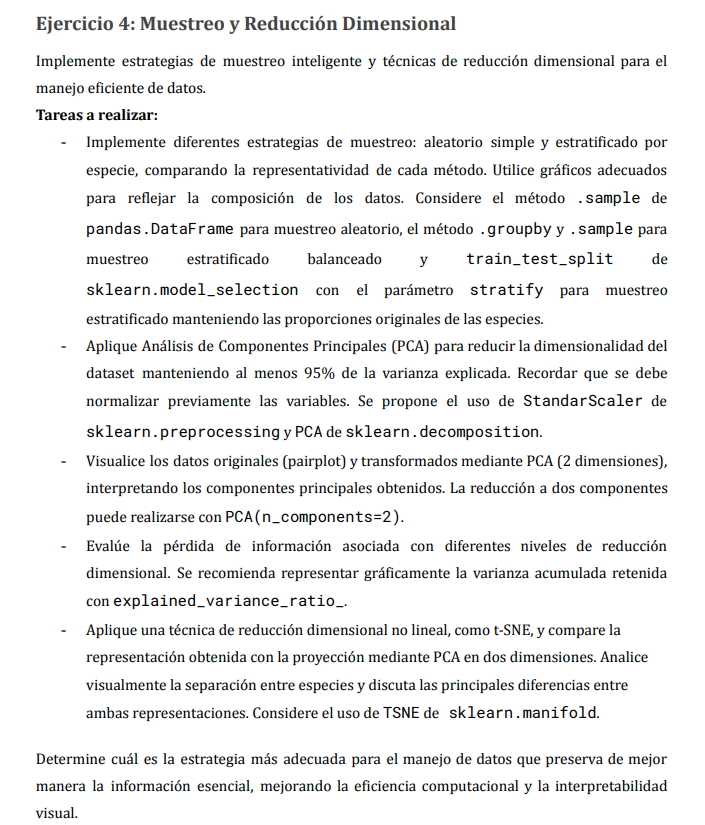

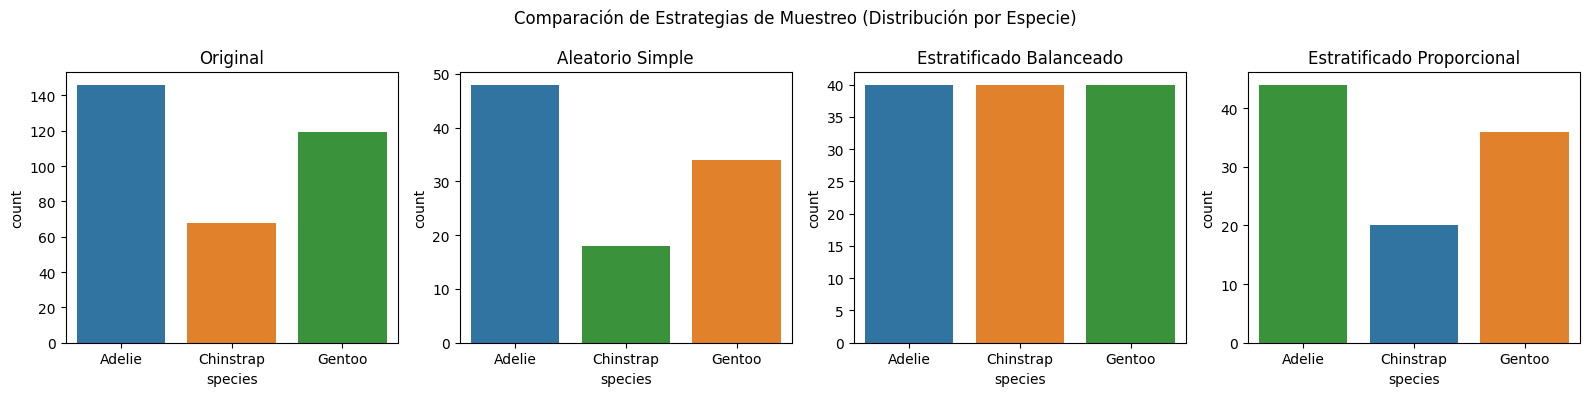

------------------------------------------------------------------------------------------
Número de componentes para retener 95% de varianza: 3
------------------------------------------------------------------------------------------


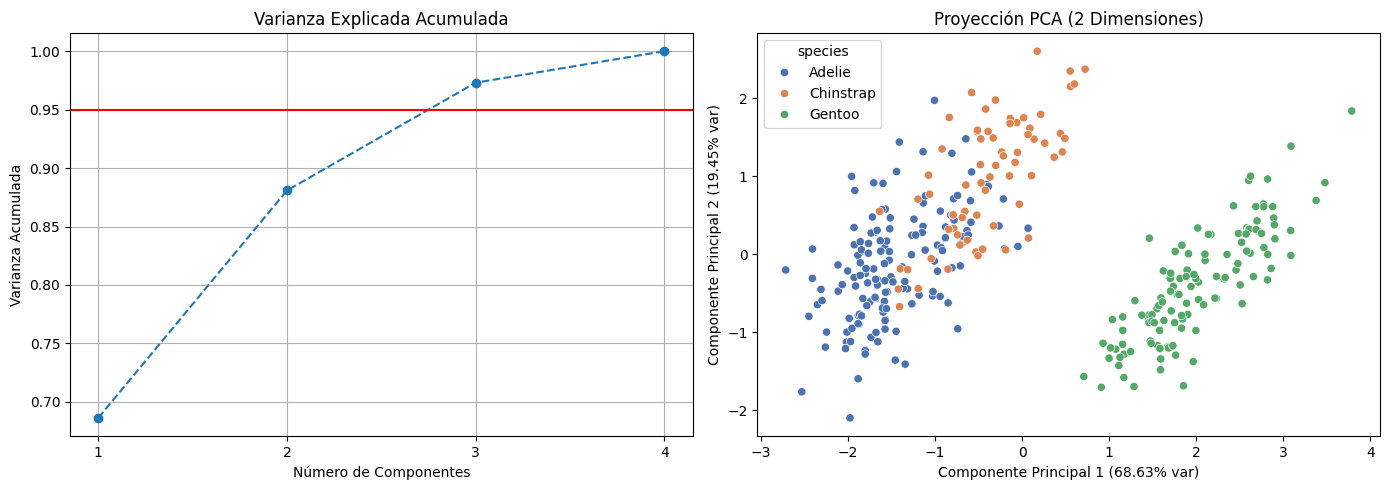

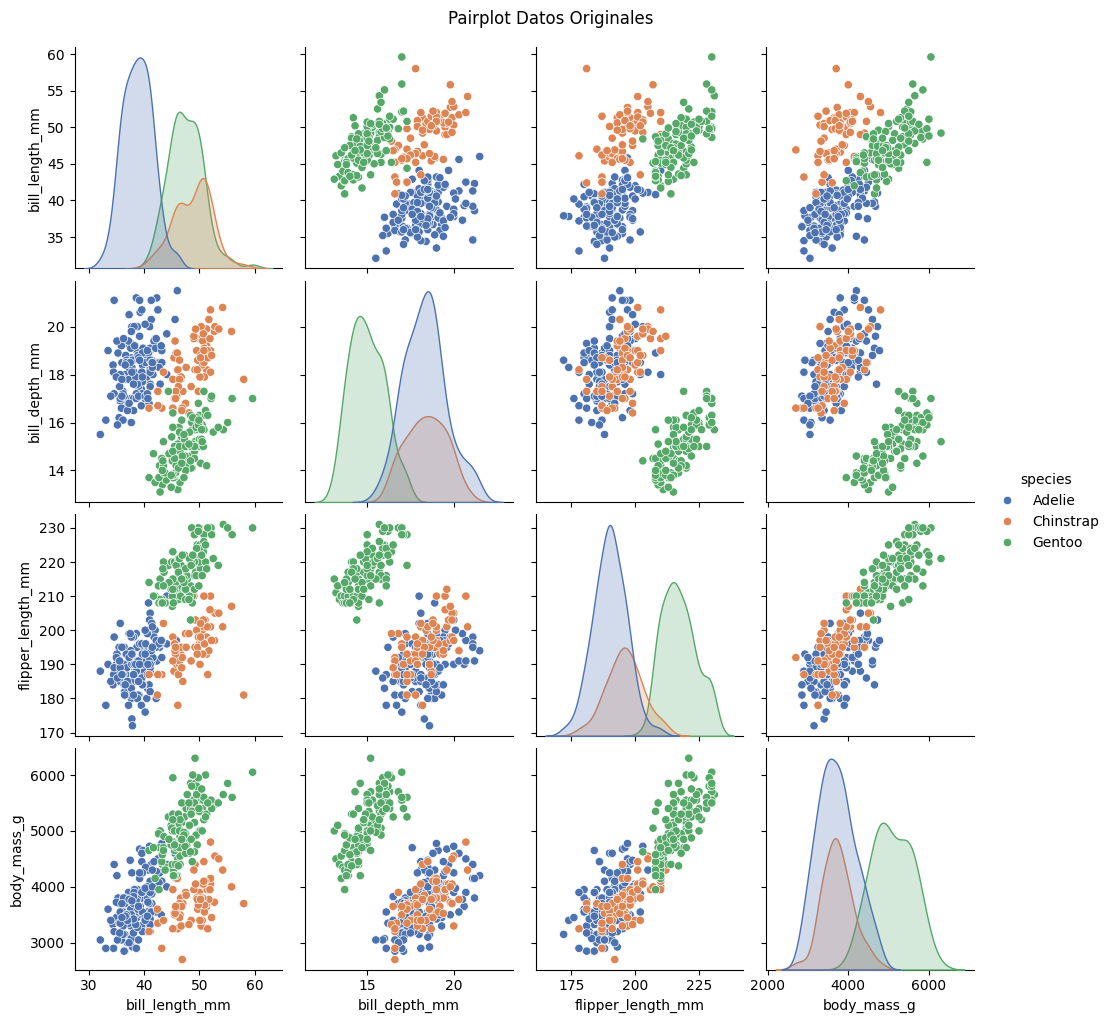

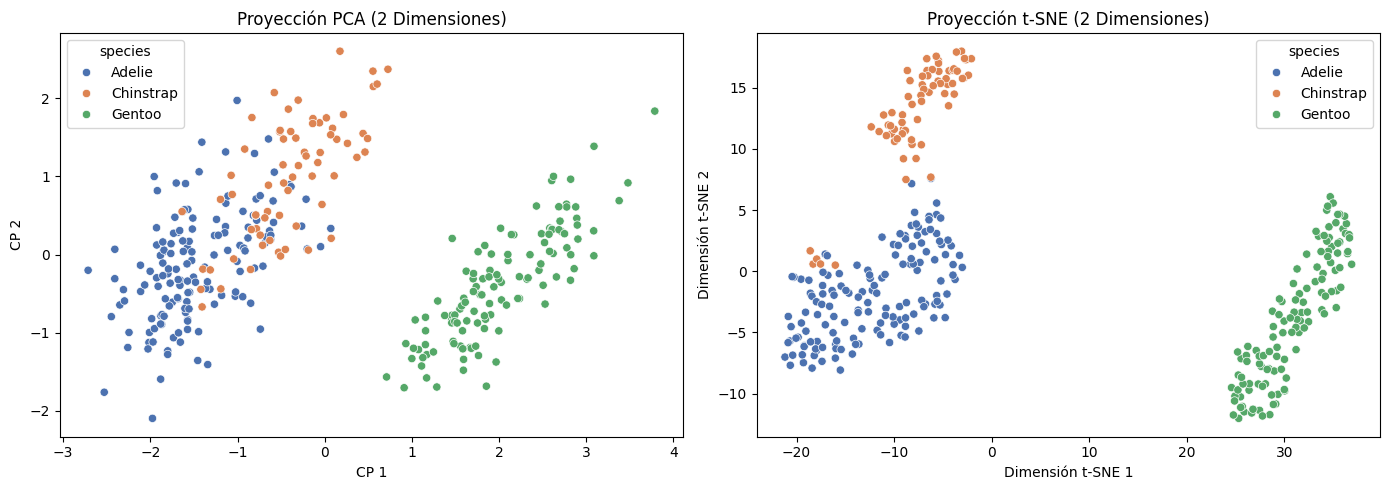

In [ ]:
datos_pinguinos = sns.load_dataset('penguins')
# Eliminamos nulos para que PCA y t-sne funcionen correctamente
df_limpia = datos_pinguinos.dropna().copy()

# Separamos las variables numéricas de las categóricas
cols_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_limpia[cols_numericas]
y = df_limpia['species']

#ahora pasamos a las distintas estrategias de muestreo

# muestreo aleatorio simple
muestra_aleatoria = df_limpia.sample(frac=0.3, random_state=42)

# muestreo estratificado balanceado (utilizando 40 individuos por especie)
#aca hay que tener cuidado de utilizar siempre un numero que sea menor o igual a la cantidad de muestras del grupo con  menos muestras. en este caso el maximo a alegir seria 68
muestra_balanceada = df_limpia.groupby('species').sample(n=40, random_state=42)

#  muestreo Estratificado proporcional (mantiene proporciones originales)
_, muestra_proporcional = train_test_split(df_limpia, test_size=0.3, stratify=df_limpia['species'], random_state=42)


# definimos un orden fijo basado en el dataset original ( esto es opcional pero es para que no se pierda el orden en el balanceado)
orden_especies = df_limpia['species'].unique()

# visualización de las composiciones
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Comparación de Estrategias de Muestreo (Distribución por Especie)')

# Agregamos order=orden_especies a todos los gráficos (nuevamente opcional)
sns.countplot(data=df_limpia, x='species', ax=axs[0], hue='species', legend=False, order=orden_especies)
axs[0].set_title('Original')

sns.countplot(data=muestra_aleatoria, x='species', ax=axs[1], hue='species', legend=False, order=orden_especies)
axs[1].set_title('Aleatorio Simple')

sns.countplot(data=muestra_balanceada, x='species', ax=axs[2], hue='species', legend=False, order=orden_especies)
axs[2].set_title('Estratificado Balanceado')

sns.countplot(data=muestra_proporcional, x='species', ax=axs[3], hue='species', legend=False, order=orden_especies)
axs[3].set_title('Estratificado Proporcional')

plt.tight_layout()
plt.show()

#PCA

# normalización previa obligatoria!!!!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA con 95% de la varianza explicada
pca_95 = PCA(n_components=0.95, random_state=42) #PCA admite valores decimales para calcular la scomponentes mínimas necesarias para capturar el 'n_components'% de la var. total.
X_pca_95 = pca_95.fit_transform(X_scaled)
print("---------"*10)
print(f"Número de componentes para retener 95% de varianza: {pca_95.n_components_}")
print("---------"*10)
# PCA de 2 componentes para visualización
pca_2 = PCA(n_components=2, random_state=42) #un n_components entero representa la cantidad de componentes que vamos a calcular.
X_pca_2 = pca_2.fit_transform(X_scaled)

# grafico de varianza acumulada
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig2, (ax_var, ax_pca) = plt.subplots(1, 2, figsize=(14, 5))

ax_var.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
ax_var.axhline(y=0.95, color='r', linestyle='-')
ax_var.set_title('Varianza Explicada Acumulada')
ax_var.set_xlabel('Número de Componentes')
ax_var.set_ylabel('Varianza Acumulada')
ax_var.set_xticks(range(1, len(varianza_acumulada) + 1))
ax_var.grid(True)

# visualización PCA (2 Dimensiones)
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=y, ax=ax_pca, palette='deep')
ax_pca.set_title('Proyección PCA (2 Dimensiones)')
ax_pca.set_xlabel(f'Componente Principal 1 ({pca_2.explained_variance_ratio_[0]:.2%} var)')
ax_pca.set_ylabel(f'Componente Principal 2 ({pca_2.explained_variance_ratio_[1]:.2%} var)')

plt.tight_layout()
plt.show()

# visualización pairplot datos originales (solo variables numéricas y especie)
sns.pairplot(df_limpia[cols_numericas + ['species']], hue='species', palette='deep')
plt.suptitle('Pairplot Datos Originales', y=1.02)
plt.show()

# REDUCCIÓN DIMENSIONAL NO LINEAL (t-SNE)

# aplicamos t-SNE sobre los datos ya normalizados
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

#t-SNE vs PCA 2D
fig3, (ax_pca2, ax_tsne) = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=y, ax=ax_pca2, palette='deep')
ax_pca2.set_title('Proyección PCA (2 Dimensiones)')
ax_pca2.set_xlabel('CP 1')
ax_pca2.set_ylabel('CP 2')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, ax=ax_tsne, palette='deep')
ax_tsne.set_title('Proyección t-SNE (2 Dimensiones)')
ax_tsne.set_xlabel('Dimensión t-SNE 1')
ax_tsne.set_ylabel('Dimensión t-SNE 2')

plt.tight_layout()
plt.show()

In [ ]:
# Muestra el peso de cada variable original en los componentes principales
pesos_pca = pd.DataFrame(
    pca_2.components_,
    columns=cols_numericas,
    index=['PC1', 'PC2']
)
print(pesos_pca)

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
PC1        0.453753      -0.399047           0.576825     0.549675
PC2        0.600195       0.796170           0.005788     0.076464


Analizando las cargas de los componentes principales obtenidos, se observa que el primer componente (PC1), que explica aproximadamente un 68% de la varianza total, está conformado por una combinación con gran presencia de las cuatro variables, pero con una fuerte predominancia de la masa corporal y el largo de la aleta. Esto indica que estas dimensiones son los factores que mayor peso tienen al explicar la variabilidad general de los datos. Por otro lado, el segundo componente principal (PC2), que junto con el PC1 permite explicar aproximadamente el 87% de la varianza total, presenta una contribución casi nula de estas dos características corporales y se centra principalmente en capturar la variabilidad morfológica del pico, representada por su largo y profundidad.

Al trasladar estos resultados a una proyección visual en dos dimensiones, el PC1 es el principal responsable de aislar claramente a la especie Gentoo de las demás, reflejando su mayor tamaño corporal y confirmando la fuerte asociación observada previamente en el análisis exploratorio. Por su parte, el PC2, relacionado principalmente con la forma del pico, permite visualizar una mejor separación entre las especies Adelie y Chinstrap, que presentan mayor similitud en cuanto a su tamaño general, pero se diferencian en las características de sus picos.

Estos resultados muestran que la reducción mediante PCA a dos dimensiones constituye un buen equilibrio entre preservación de la información, eficiencia computacional e interpretabilidad visual. Con un solo componente es posible conservar aproximadamente el 68% de la varianza original, por lo que incluso una representación unidimensional mantendría una parte importante de la estructura de los datos. Sin embargo, incorporar el segundo componente permite aumentar la varianza explicada en aproximadamente 19 puntos porcentuales, alcanzando el 87%. De esta manera, una gran parte de la información original puede representarse en un espacio bidimensional, lo que facilita considerablemente la visualización e interpretación de las relaciones entre las especies.

Si el objetivo fuera preservar una proporción aún mayor de la variabilidad original, sería necesario incorporar un tercer componente, alcanzando más del 95% de la varianza explicada y reduciendo la proporción de información no representada a aproximadamente un 3%. No obstante, esta alternativa implica perder parte de la simplicidad de la representación visual, ya que el análisis deja de realizarse en un plano bidimensional. Por este motivo, para un análisis que busque simultáneamente conservar la información esencial y facilitar su interpretación visual, la representación mediante PCA en dos dimensiones resulta la alternativa más adecuada.

Por otro lado, al aplicar t-SNE, una técnica de reducción dimensional no lineal, se observa que la representación logra formar clústeres más definidos y separados entre las tres especies, superando la superposición que se observa entre Adelie y Chinstrap en la representación mediante PCA. Esto hace que t-SNE sea particularmente útil cuando el objetivo principal es explorar visualmente la existencia de agrupamientos en los datos. Sin embargo, sus dimensiones no poseen una interpretación directa y no permiten determinar de manera sencilla qué proporción de la variabilidad corresponde a cada componente ni qué peso tiene cada variable original, como sí ocurre con PCA.

Por lo tanto, considerando conjuntamente la preservación de la información, la eficiencia computacional y la interpretabilidad visual, la estrategia más adecuada para este conjunto de datos es utilizar PCA con dos componentes principales. Esta representación conserva aproximadamente el 87% de la varianza original y permite visualizar en un plano las principales diferencias morfológicas entre las especies, manteniendo además una interpretación clara de la contribución de las variables originales. t-SNE puede utilizarse como una herramienta complementaria para explorar agrupamientos no lineales, pero no resulta tan conveniente como estrategia principal cuando también se busca interpretar y cuantificar la información preservada.


#Ejercicio 5

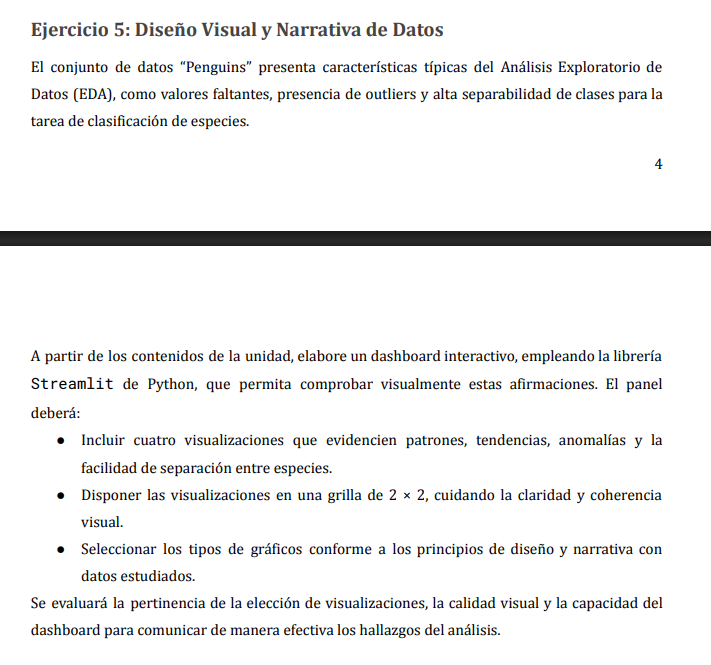

In [ ]:
!pip install -q streamlit seaborn scikit-learn

In [ ]:
!wget -q -nc -O cloudflared-linux-amd64 https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


#Configuracion de la pagina

st.set_page_config(
    page_title="EDA & Separabilidad - Palmer Penguins",
    page_icon="🐧",
    layout="wide"
)

st.title("🐧 Penguins: Análisis Exploratorio y Separabilidad de Especies")
st.markdown(
    """
    Dashboard interactivo organizado en **4 etapas**:
    1. **Estructura individual y outliers** *(Boxplot)*
    2. **Ocupación del espacio de variables** *(Scatterplot)*
    3. **Estructura global e intra-especie de correlación** *(Heatmap)*
    4. **Síntesis y separabilidad multivariada** *(PCA 2D)*
    """
)


@st.cache_data
def cargar_datos():
    df = sns.load_dataset("penguins")
    variables_num = [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g"
    ]
    df = df.dropna(subset=variables_num + ["species", "island"])
    return df, variables_num

datos_base, variables_numericas = cargar_datos()


st.sidebar.header("🔍 Filtros de Selección")

especies_seleccionadas = st.sidebar.multiselect(
    "Filtrar por Especie:",
    options=list(datos_base["species"].unique()),
    default=list(datos_base["species"].unique())
)

islas_seleccionadas = st.sidebar.multiselect(
    "Filtrar por Isla:",
    options=list(datos_base["island"].unique()),
    default=list(datos_base["island"].unique())
)

datos = datos_base[
    (datos_base["species"].isin(especies_seleccionadas)) &
    (datos_base["island"].isin(islas_seleccionadas))
]

if datos.empty:
    st.warning("⚠️ No hay observaciones para los filtros seleccionados.")
    st.stop()


col1, col2 = st.columns(2)


#BOXPLOT: DISTRIBUCIÓN Y ANOMALÍAS

with col1:
    st.subheader("1. Distribución y Detección de Outliers")

    variable_boxplot = st.selectbox(
        "Variable a examinar:",
        variables_numericas,
        key="var_box"
    )

    fig1 = px.box(
        datos,
        x="species",
        y=variable_boxplot,
        color="species",
        points="all",
        hover_data=["island", "sex"],
        title=f"Distribución de {variable_boxplot} por Especie"
    )
    fig1.update_layout(height=420, showlegend=False, margin=dict(l=20, r=20, t=40, b=20))
    st.plotly_chart(fig1, use_container_width=True)
    st.caption("💡 Muestra rango intercuartílico, medianas y detecta valores atípicos.")


#SCATTERPLOT: RELACIÓN ENTRE VARIABLES
with col2:
    st.subheader("2. Relación Bivariada entre Características")

    cx, cy = st.columns(2)
    with cx:
        var_x = st.selectbox("Variable X:", variables_numericas, index=0, key="scat_x")
    with cy:
        var_y = st.selectbox("Variable Y:", variables_numericas, index=1, key="scat_y")

    fig2 = px.scatter(
        datos,
        x=var_x,
        y=var_y,
        color="species",
        symbol="sex",
        hover_data=["island", "body_mass_g"],
        title=f"Relación: {var_x} vs {var_y}"
    )
    fig2.update_layout(height=420, margin=dict(l=20, r=20, t=40, b=20))
    st.plotly_chart(fig2, use_container_width=True)
    st.caption("💡 Evalúa solapamientos o clusters entre pares de variables.")


# HEATMAP: ESTRUCTURA GLOBAL E INTRA-ESPECIE
with col1:
    st.subheader("3. Estructura de Correlación")

    opciones_heat = ["Todas las especies"] + list(datos["species"].unique())
    especie_matriz = st.radio(
        "Matriz para:",
        opciones_heat,
        horizontal=True,
        key="heat_radio"
    )

    if especie_matriz == "Todas las especies":
        df_corr = datos[variables_numericas]
    else:
        df_corr = datos[datos["species"] == especie_matriz][variables_numericas]

    correlaciones = df_corr.corr()

    fig3 = px.imshow(
        correlaciones,
        text_auto=".2f",
        color_continuous_scale="rdbu",
        zmin=-1, zmax=1,
        title=f"Matriz de Correlación ({especie_matriz})"
    )
    fig3.update_layout(height=420, margin=dict(l=20, r=20, t=40, b=20))
    st.plotly_chart(fig3, use_container_width=True)
    st.caption("💡 Evalúa colinealidad global o comportamientos dentro de cada especie.")

# PCA: REDUCCIÓN Y SEPARABILIDAD
with col2:
    st.subheader("4. Reducción Dimensional & Separabilidad (PCA)")

    if len(datos) >= 2:
        X = datos[variables_numericas]
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)

        df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=datos.index)
        df_pca["species"] = datos["species"]
        df_pca["island"] = datos["island"]

        var_pc1 = pca.explained_variance_ratio_[0] * 100
        var_pc2 = pca.explained_variance_ratio_[1] * 100

        fig4 = px.scatter(
            df_pca,
            x="PC1",
            y="PC2",
            color="species",
            hover_data=["island"],
            labels={
                "PC1": f"PC1 ({var_pc1:.1f}% var)",
                "PC2": f"PC2 ({var_pc2:.1f}% var)"
            },
            title=f"Proyección 2D - Varianza Explicada: {var_pc1 + var_pc2:.1f}%"
        )
        fig4.update_layout(height=420, margin=dict(l=20, r=20, t=40, b=20))
        st.plotly_chart(fig4, use_container_width=True)
        st.caption("💡 Resume las 4 variables en 2D para mostrar separabilidad de clases.")
    else:
        st.info("Insuficientes datos para calcular PCA.")

Overwriting app.py


In [ ]:
import subprocess
import time
import re

!pkill -f streamlit
!pkill -f cloudflared

#Iniciar Streamlit
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"])
time.sleep(3)

#Iniciar Cloudflare Tunnel guardando logs en un archivo
!./cloudflared-linux-amd64 tunnel --url http://localhost:8501 --logfile cloudflare.log > /dev/null 2>&1 &

#Esperar a que la URL esté lista
url = None
for _ in range(15):
    time.sleep(1)
    try:
        with open("cloudflare.log", "r") as f:
            log_content = f.read()
            match = re.search(r"https://[a-zA-Z0-9-]+\.trycloudflare\.com", log_content)
            if match:
                url = match.group(0)
                break
    except FileNotFoundError:
        continue

if url:
    print(f"\n🚀 Dashboard activo y estable en:\n👉 {url}\n")
else:
    print("No se pudo obtener la URL. Revisa si cloudflare.log contiene errores.")


🚀 Dashboard activo y estable en:
👉 https://shareware-concern-jennifer-social.trycloudflare.com



La combinación de estos cuatro gráficos se eligió porque construye una narrativa progresiva e incremental, pasando del análisis univariado al multivariado: el Boxplot abre el recorrido explorando la distribución individual de las variables y detectando valores atípicos; el Scatterplot avanza hacia la relación bivariada para observar cómo interaccionan dos características concretas entre especies; el Heatmap amplía la perspectiva a la estructura de correlación global e intra-especie para identificar colinealidades o paradojas de comportamiento; y, finalmente, el PCA 2D sintetiza todas las dimensiones en un resumen visual claro que demuestra el grado real de separabilidad entre los grupos.